In [1]:
# useful to autoreload the module without restarting the kernel
%load_ext autoreload
%autoreload 2

In [2]:
from mppi import Parsers as P, Optics as O
from mppi.Utilities import Constants as Const
from mppi.Utilities import Utils
import matplotlib.pyplot as plt
import numpy as np
import os, re

# Non-linear $\chi$ of LiF and transient absorption

We extract the equilibrium (non-linear) susceptibilities of LiF from the `yambo_nl` simulations performed in
`YamboNL_Analysis.ipynb`. They are the ingredients for the description of the transient absorption in terms of the
non-linear $\chi$, to be compared with the RT simulations of D. Sangalli (one run for each pump-probe delay).

The first part of the notebook analyzes the $\chi$ order by order. The construction of the transient absorption is
collected at the end of the notebook (not yet revised).

Reference: `../References/Pp_and_non_linear_functions.pdf` (C. Attaccalite, D. Sangalli).

## Extraction of the non-linear $\chi$

We use the three simulations of `YamboNL_Analysis.ipynb` (bands 3-6, field along x):

- `lresponse-bands_3-6-delta`: single delta pulse (intensity 1e3 kW/m$^2$, no damping);
- `pulse-E1_1e3-nlenrange_10.0-20.0-nlensteps_201-bands_3-6-damp_0.1-sin`: one sine-shaped probe for each frequency
  in the 10-20 eV range (intensity 1e3 kW/m$^2$, damping 0.1 eV);
- `Pp-Ep_1e3-EP_1e6-PE_1.55-nlenrange_10.0-20.0-nlensteps_201-bands_3-6-damp_0.1-sin`: the same probes combined with a
  sine-shaped pump at 1.55 eV (intensity 1e6 kW/m$^2$).

All the $\chi$ are in atomic units ($P = \chi E$) and follow the conventions of MPPI >= 1.3 (Boyd, Sec. 1.3):
$E(t) = \sum_n E(\omega_n)e^{-i\omega_n t}$ with $E(\omega) = (iE_0/2)e^{i\omega t_0}$ for a sine field.

In [3]:
run_dir = 'kx8_nb100_NoTr_E100'
file_delta = os.path.join(run_dir,'lresponse-bands_3-6-delta','ndb.Nonlinear')
file_pulse = os.path.join(run_dir,'pulse-E1_1e3-nlenrange_10.0-20.0-nlensteps_201-bands_3-6-damp_0.1-sin','ndb.Nonlinear')
file_Pp = os.path.join(run_dir,'Pp-Ep_1e3-EP_1e6-PE_1.55-nlenrange_10.0-20.0-nlensteps_201-bands_3-6-damp_0.1-sin','ndb.Nonlinear')
data_delta = P.YamboNLDBParser(file_delta)
data_pulse = P.YamboNLDBParser(file_pulse)
data_Pp = P.YamboNLDBParser(file_Pp)

Parse file : kx8_nb100_NoTr_E100/lresponse-bands_3-6-delta/ndb.Nonlinear
Parse file : kx8_nb100_NoTr_E100/pulse-E1_1e3-nlenrange_10.0-20.0-nlensteps_201-bands_3-6-damp_0.1-sin/ndb.Nonlinear


Parse file : kx8_nb100_NoTr_E100/Pp-Ep_1e3-EP_1e6-PE_1.55-nlenrange_10.0-20.0-nlensteps_201-bands_3-6-damp_0.1-sin/ndb.Nonlinear


Harmonic analysis of the sine and frequency mixing runs. For the probe-only runs we fit the harmonics up to the third
one (the keys 0, 1, 2, 3 are the static term and the harmonics of the probe), for the frequency mixing runs the
combinations up to the first order in the probe and the second order in the pump (keys $(n,m)$: $n$ times the probe and
$m$ times the pump frequency).

In [4]:
single_freq = O.Xn_single_frequency(data_pulse,X_order=3,verbose=False)
freq_mix = O.Xn_frequency_mixing(data_Pp,X_order=(1,2),verbose=False)
chi_sin = single_freq.compute_Xn(set_units_of_measure=False)[0]
chi_freqmix = freq_mix.compute_Xn(set_units_of_measure=False)[0]
chi_sin.keys(), chi_freqmix.keys()

(dict_keys([0, 1, 2, 3]),
 dict_keys([(0, 0), (1, 0), (0, 1), (0, 2), (1, 1), (1, -1), (1, 2), (1, -2)]))

Probe frequencies (Hartree and eV), pump frequency (Hartree) and amplitudes $E_0$ of the fields (au)

In [5]:
omega = freq_mix.probe_freqs
freqs = omega*Const.HaToeV
omega_P = freq_mix.pump_freq
Ep = data_Pp.Efield[0]['amplitude']
EP = data_Pp.Efield2[0]['amplitude']
print('probe range (eV): %.3f - %.3f, step %.4f eV'%(freqs[0],freqs[-1],freqs[1]-freqs[0]))
print('pump frequency (eV): %.3f'%(omega_P*Const.HaToeV))
print('probe amplitude E0 (au): %.3e - pump amplitude E0 (au): %.3e'%(Ep,EP))

probe range (eV): 10.000 - 19.950, step 0.0498 eV
pump frequency (eV): 1.550
probe amplitude E0 (au): 3.775e-06 - pump amplitude E0 (au): 1.194e-04


### Linear susceptibility

We compute $\chi^{(1)}(\omega)$ in three independent ways:

- **delta**: from the FT of the polarization induced by the delta pulse, $\chi^{(1)} = (\epsilon-1)/4\pi$ with
  `Linear_Response`. The run has no damping, so a Lorentzian damping $\eta$ = 0.1 eV (equal to the damping of the
  sine runs) is applied in the FT;
- **sine**: the first harmonic of the probe-only runs, `chi_sin[1]`;
- **P&p**: the key $(1,0)$ of the frequency mixing runs. This term also contains the pump induced third order
  contribution $\chi_{(1,1,-1)}|E_P(\omega_P)|^2$, so it is expected to differ slightly from the other two.

In [6]:
eta = 0.1 # eV
energy_delta, eps_delta = O.Linear_Response(data_delta.IO_TIME_points,data_delta.Polarization[0],data_delta.Efield[0],eta=eta)
chi1_delta_full = (eps_delta-1)/(4*np.pi)
# interpolation on the probe grid of the sine runs
chi1_delta = np.interp(freqs,energy_delta,chi1_delta_full.real) + 1j*np.interp(freqs,energy_delta,chi1_delta_full.imag)
chi1_sin = chi_sin[1]
chi1_Pp = chi_freqmix[(1,0)]

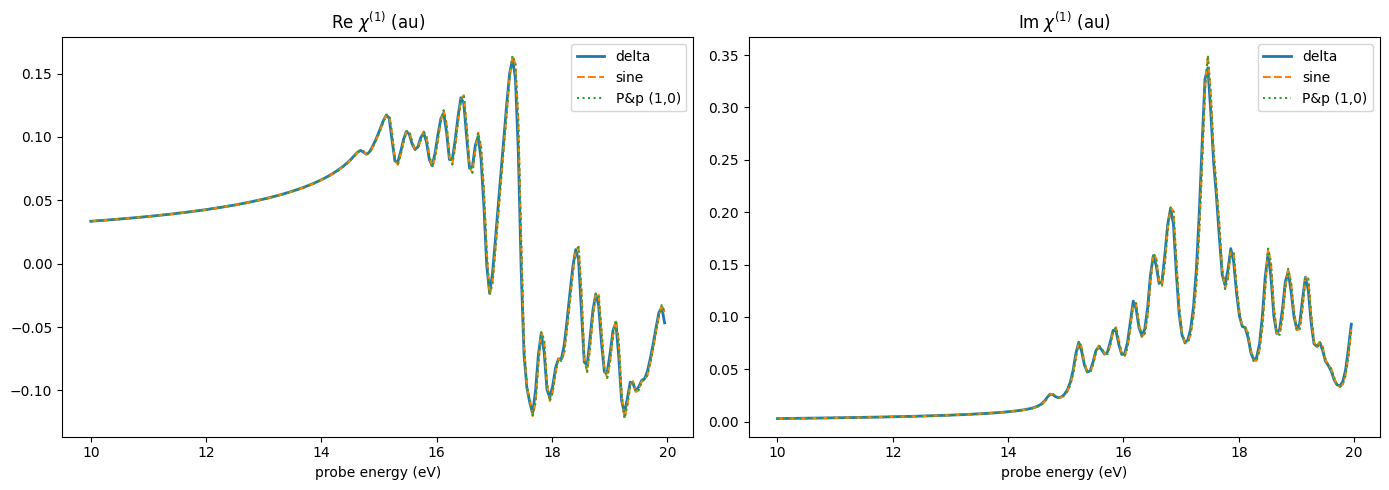

In [7]:
fig,axes = plt.subplots(1,2,figsize=(14,5))
for ax,part,lab in zip(axes,[np.real,np.imag],['Re','Im']):
    ax.plot(freqs,part(chi1_delta),label='delta',lw=2)
    ax.plot(freqs,part(chi1_sin),'--',label='sine')
    ax.plot(freqs,part(chi1_Pp),':',label='P&p (1,0)')
    ax.set_xlabel('probe energy (eV)')
    ax.set_title(r'%s $\chi^{(1)}$ (au)'%lab)
    ax.legend()
plt.tight_layout()

Relative differences between the three estimates, $|\chi_a - \chi_b|/|\chi_b|$

sine vs delta  max 1.05e-01  mean 2.71e-02
P&p vs delta   max 1.05e-01  mean 2.71e-02
P&p vs sine    max 2.08e-03  mean 1.90e-04


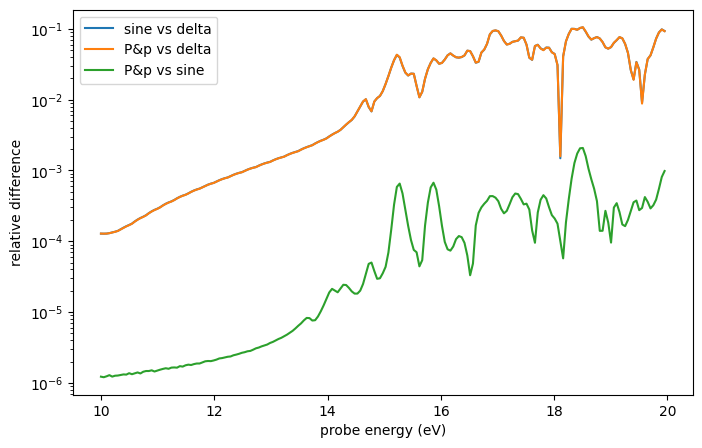

In [8]:
rel = lambda a,b : np.abs(a-b)/np.abs(b)
plt.figure(figsize=(8,5))
plt.semilogy(freqs,rel(chi1_sin,chi1_delta),label='sine vs delta')
plt.semilogy(freqs,rel(chi1_Pp,chi1_delta),label='P&p vs delta')
plt.semilogy(freqs,rel(chi1_Pp,chi1_sin),label='P&p vs sine')
plt.xlabel('probe energy (eV)')
plt.ylabel('relative difference')
plt.legend()
for lab,a,b in [('sine vs delta',chi1_sin,chi1_delta),('P&p vs delta',chi1_Pp,chi1_delta),('P&p vs sine',chi1_Pp,chi1_sin)]:
    print('%-14s max %.2e  mean %.2e'%(lab,np.max(rel(a,b)),np.mean(rel(a,b))))

### Second order susceptibility

LiF (rock salt, space group $Fm\bar{3}m$) is centrosymmetric: under inversion $P\to-P$ and $E\to-E$, so all the
even order susceptibilities vanish. In the present simulations this means that the following terms must be zero
within the numerical accuracy:

- probe-only runs: the second harmonic `chi_sin[2]` $=\chi^{(2)}(2\omega;\omega,\omega)$ and the static term
  `chi_sin[0]` (optical rectification, $2\chi^{(2)}(0;\omega,-\omega)$);
- frequency mixing runs: the sum and difference frequency terms
  $\chi_{(1,\pm1)} = 2\chi^{(2)}(\omega\pm\omega_P;\omega,\pm\omega_P)$, the second harmonic of the pump $\chi_{(0,2)}$
  and its static term $\chi_{(0,0)}$.

To assess their size we compare the polarization they produce with the linear one: the ratio between the second order
and the linear component of $P$ is $|\chi^{(2)}||E|/|\chi^{(1)}|$, with $|E(\omega)| = E_0/2$ the amplitude of the
additional field that enters the second order term.

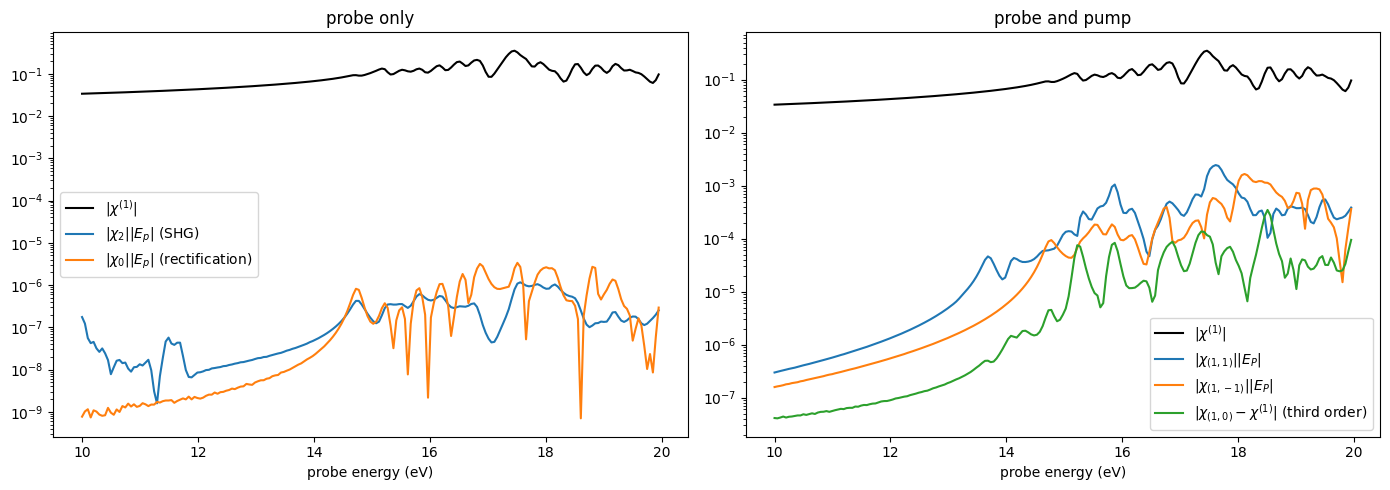

In [9]:
abs_Ep, abs_EP = Ep/2, EP/2
fig,axes = plt.subplots(1,2,figsize=(14,5))
ax = axes[0]
ax.semilogy(freqs,np.abs(chi1_sin),'k',label=r'$|\chi^{(1)}|$')
ax.semilogy(freqs,np.abs(chi_sin[2])*abs_Ep,label=r'$|\chi_{2}||E_p|$ (SHG)')
ax.semilogy(freqs,np.abs(chi_sin[0])*abs_Ep,label=r'$|\chi_{0}||E_p|$ (rectification)')
ax.set_title('probe only')
ax = axes[1]
ax.semilogy(freqs,np.abs(chi1_sin),'k',label=r'$|\chi^{(1)}|$')
ax.semilogy(freqs,np.abs(chi_freqmix[(1,1)])*abs_EP,label=r'$|\chi_{(1,1)}||E_P|$')
ax.semilogy(freqs,np.abs(chi_freqmix[(1,-1)])*abs_EP,label=r'$|\chi_{(1,-1)}||E_P|$')
ax.semilogy(freqs,np.abs(chi1_Pp-chi1_sin),label=r'$|\chi_{(1,0)}-\chi^{(1)}|$ (third order)')
ax.set_title('probe and pump')
for ax in axes:
    ax.set_xlabel('probe energy (eV)')
    ax.legend()
plt.tight_layout()

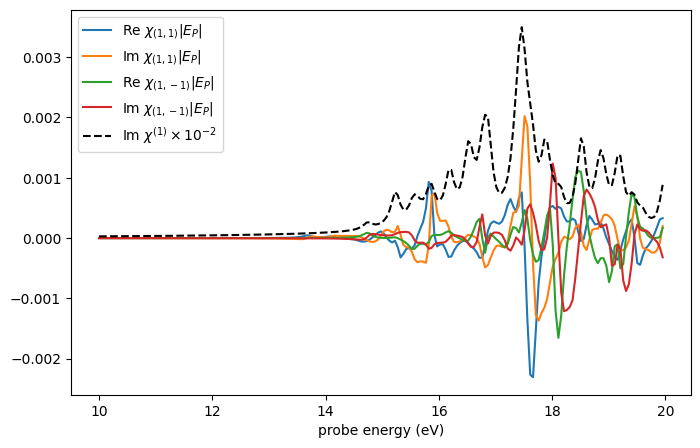

In [10]:
plt.figure(figsize=(8,5))
plt.plot(freqs,np.real(chi_freqmix[(1,1)])*abs_EP,label=r'Re $\chi_{(1,1)}|E_P|$')
plt.plot(freqs,np.imag(chi_freqmix[(1,1)])*abs_EP,label=r'Im $\chi_{(1,1)}|E_P|$')
plt.plot(freqs,np.real(chi_freqmix[(1,-1)])*abs_EP,label=r'Re $\chi_{(1,-1)}|E_P|$')
plt.plot(freqs,np.imag(chi_freqmix[(1,-1)])*abs_EP,label=r'Im $\chi_{(1,-1)}|E_P|$')
plt.plot(freqs,1e-2*np.imag(chi1_sin),'k--',label=r'Im $\chi^{(1)}\times 10^{-2}$')
plt.xlabel('probe energy (eV)')
plt.legend()

Summary of the size of the second order terms w.r.t. the linear response. For the pump alone we use the ratio between
the component of $P$ at $2\omega_P$ (and the static one) and the linear component at $\omega_P$, computed in each run
(it should not depend on the probe frequency).

In [11]:
r_02 = np.abs(chi_freqmix[(0,2)])*abs_EP/np.abs(chi_freqmix[(0,1)])
r_00 = np.abs(chi_freqmix[(0,0)])*abs_EP/np.abs(chi_freqmix[(0,1)])
print('pump SHG / linear            : min %.2e max %.2e'%(r_02.min(),r_02.max()))
print('pump static / linear         : min %.2e max %.2e'%(r_00.min(),r_00.max()))
print('max |chi_(1,+1)||E_P|/|chi1| : %.2e'%np.max(np.abs(chi_freqmix[(1,1)])*abs_EP/np.abs(chi1_sin)))
print('max |chi_(1,-1)||E_P|/|chi1| : %.2e'%np.max(np.abs(chi_freqmix[(1,-1)])*abs_EP/np.abs(chi1_sin)))
print('max |chi_2||E_p|/|chi1|      : %.2e'%np.max(np.abs(chi_sin[2])*abs_Ep/np.abs(chi1_sin)))
print('max |chi_0||E_p|/|chi1|      : %.2e'%np.max(np.abs(chi_sin[0])*abs_Ep/np.abs(chi1_sin)))

pump SHG / linear            : min 3.11e-07 max 3.36e-07
pump static / linear         : min 1.57e-17 max 1.73e-14
max |chi_(1,+1)||E_P|/|chi1| : 1.09e-02
max |chi_(1,-1)||E_P|/|chi1| : 1.79e-02
max |chi_2||E_p|/|chi1|      : 1.01e-05
max |chi_0||E_p|/|chi1|      : 2.13e-05


### Diagnostics of the mixing terms $\chi_{(1,\pm1)}$

The second order terms of the single fields vanish within the numerical accuracy (the second harmonic of the pump is
$\sim 3\cdot 10^{-7}$ of its linear response), so the dynamics respects the inversion symmetry. On the contrary the
mixing terms $\chi_{(1,\pm1)}|E_P|$ reach $1-2\cdot 10^{-2}$ of $\chi^{(1)}$, i.e. they are about 10 times larger than
the third order pump induced term $\chi_{(1,0)}-\chi^{(1)}$, which is the physical effect that we want to describe.
Moreover they follow the resonances of the probe. Since they must vanish by symmetry, we investigate where they come
from with two tests:

1. **Harmonics included in the fit.** The harmonic analysis fits the polarization in the last part of the simulation
   with a sum of sines at the frequencies $n\omega+m\omega_P$ selected by `X_order`. A component of $P(t)$ that is
   present in the signal but not included in the fit (e.g. the third harmonic of the pump $3\omega_P$ or the terms
   $\omega\pm3\omega_P$) is partially projected on the fitted ones, and the effect is largest on the weakest terms. We
   repeat the analysis with `X_order=(1,3)`: if the $(1,\pm1)$ terms are due to missing harmonics they should change.
2. **Spectrum of the raw polarization.** Independently of the fit, we compute the amplitude spectrum of $P(t)$ of a
   few runs in a long time window (from the dephasing time to the end of the simulation) and we compare the amplitude
   of the peaks at $\omega\pm\omega_P$ with the ones obtained from the fit. We also compute the residual of the fit
   (polarization minus fitted signal) and its spectrum, to detect components that the fit does not describe.
   If the peaks at $\omega\pm\omega_P$ are present in $P(t)$ with the fitted amplitude, the $(1,\pm1)$ terms are in the
   polarization computed by `yambo_nl` and are not an artifact of the harmonic analysis.

#### Test 1: harmonic analysis with `X_order=(1,3)`

In [12]:
freq_mix13 = O.Xn_frequency_mixing(data_Pp,X_order=(1,3),verbose=False)
chi_freqmix13 = freq_mix13.compute_Xn(set_units_of_measure=False)[0]
chi_freqmix13.keys()

dict_keys([(0, 0), (1, 0), (0, 1), (0, 2), (0, 3), (1, 1), (1, -1), (1, 2), (1, -2), (1, 3), (1, -3)])

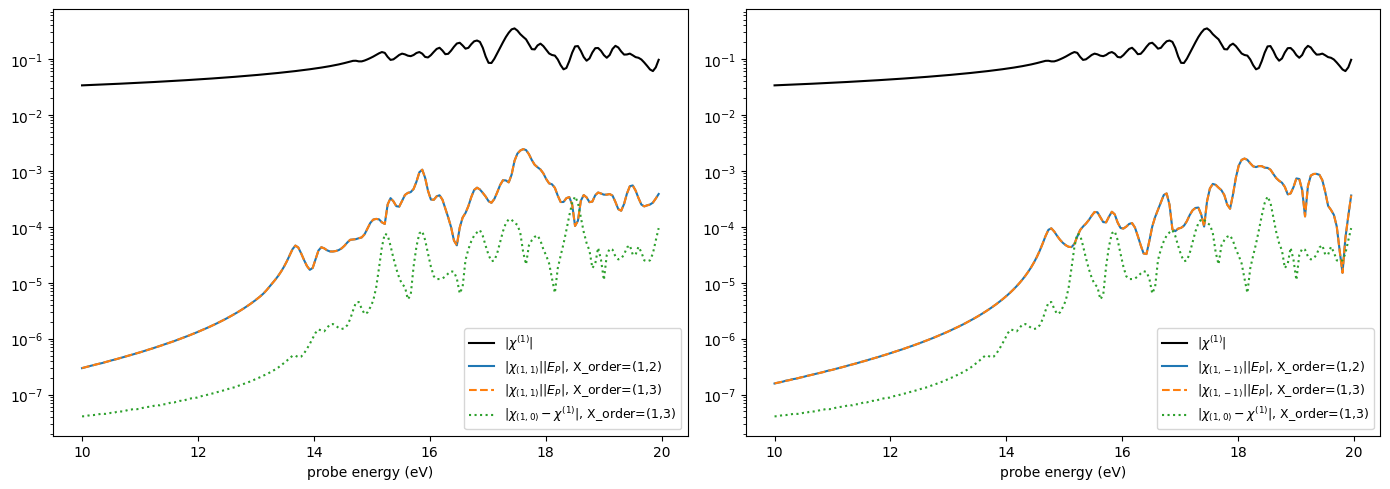

In [13]:
fig,axes = plt.subplots(1,2,figsize=(14,5))
for ax,key in zip(axes,[(1,1),(1,-1)]):
    ax.semilogy(freqs,np.abs(chi1_sin),'k',label=r'$|\chi^{(1)}|$')
    ax.semilogy(freqs,np.abs(chi_freqmix[key])*abs_EP,label=r'$|\chi_{%s}||E_P|$, X_order=(1,2)'%str(key))
    ax.semilogy(freqs,np.abs(chi_freqmix13[key])*abs_EP,'--',label=r'$|\chi_{%s}||E_P|$, X_order=(1,3)'%str(key))
    ax.semilogy(freqs,np.abs(chi_freqmix13[(1,0)]-chi1_sin),':',label=r'$|\chi_{(1,0)}-\chi^{(1)}|$, X_order=(1,3)')
    ax.set_xlabel('probe energy (eV)')
    ax.legend(fontsize=9)
plt.tight_layout()

In [14]:
print('relative change of the keys from X_order=(1,2) to X_order=(1,3): max|chi13-chi12|/max|chi12|')
for key in [(1,0),(1,1),(1,-1),(1,2),(1,-2)]:
    print('  %-8s %.2e'%(str(key),np.max(np.abs(chi_freqmix13[key]-chi_freqmix[key]))/np.max(np.abs(chi_freqmix[key]))))
print('third order part of (1,0): max|(chi13-chi12)(1,0)|/max|chi12(1,0)-chi1| = %.2e'%(
      np.max(np.abs(chi_freqmix13[(1,0)]-chi_freqmix[(1,0)]))/np.max(np.abs(chi_freqmix[(1,0)]-chi1_sin))))
# size of the new harmonics w.r.t. the linear components (ratio of the polarization components)
r_03 = np.abs(chi_freqmix13[(0,3)])*abs_EP**2/np.abs(chi_freqmix13[(0,1)])
print('pump third harmonic / pump linear     : min %.2e max %.2e'%(r_03.min(),r_03.max()))
for key in [(1,3),(1,-3)]:
    print('max |chi_%s||E_P|^3/|chi1|         : %.2e'%(str(key),np.max(np.abs(chi_freqmix13[key])*abs_EP**3/np.abs(chi1_sin))))

relative change of the keys from X_order=(1,2) to X_order=(1,3): max|chi13-chi12|/max|chi12|
  (1, 0)   4.24e-09
  (1, 1)   5.72e-07
  (1, -1)  1.25e-06
  (1, 2)   3.40e-05
  (1, -2)  8.22e-05
third order part of (1,0): max|(chi13-chi12)(1,0)|/max|chi12(1,0)-chi1| = 4.28e-06
pump third harmonic / pump linear     : min 1.06e-07 max 1.16e-07
max |chi_(1, 3)||E_P|^3/|chi1|         : 3.92e-06
max |chi_(1, -3)||E_P|^3/|chi1|         : 2.57e-06


**Results of test 1.** Adding the harmonics $(0,3)$ and $(1,\pm3)$ to the fit leaves the $(1,\pm1)$ terms unchanged
(relative change $\sim 10^{-6}$; the two curves in the plot are superimposed) and changes the third order keys by less
than $10^{-4}$. The new harmonics are tiny: the third harmonic of the pump is $\sim 10^{-7}$ of its linear response and
$|\chi_{(1,\pm3)}||E_P|^3$ is $\lesssim 4\cdot 10^{-6}$ of $\chi^{(1)}$. The hypothesis of missing harmonics in the fit is
therefore ruled out: the fit with `X_order=(1,2)` is complete at this level of accuracy. (The warnings on the time
window come from the lowest probe frequencies, for which $\omega-3\omega_P$ gets close to $3\omega_P$; they do not
affect the conclusion.)

#### Test 2: spectrum of the raw polarization and residual of the fit

For a few probe frequencies we compute the amplitude spectrum of $P_x(t)$
$$
A(\Omega) = \frac{2\left|\sum_t w(t)P_x(t)e^{i\Omega t}\right|}{\sum_t w(t)}
$$
with a Hann window $w(t)$, which gives the amplitude $A$ of a component $A\sin(\Omega t+\phi)$ at its frequency. The window
goes from the dephasing time (79 fs) to the end of the simulation (200 fs), so the frequency resolution
($2\pi/T \simeq 0.03$ eV) is much better than the spacing $\omega_P$ = 1.55 eV of the harmonics. The amplitudes at the
frequencies of the fit are compared with the fitted ones (`X_order=(1,2)`, last 21.35 fs of the simulation).
The residual of the fit is computed in the fit window and its spectrum is shown in the same plot.

In [15]:
from mppi.Optics.Xn_frequency_mixing import generate_frequencies
from mppi.Optics.Utils import eval_sum_frequencies

def amplitude_spectrum(t, y, Omegas):
    # amplitude of the sinusoidal components of y(t) at the frequencies Omegas, with a Hann window
    w = np.hanning(len(t))
    y = y - np.sum(w*y)/np.sum(w)
    return np.array([2*np.abs(np.sum(w*y*np.exp(1j*Om*t)))/np.sum(w) for Om in Omegas])

time = np.array(data_Pp.IO_TIME_points)
pol_Pp = np.array(data_Pp.Polarization)
i_deph = np.argmin(np.abs(time-freq_mix.deph))
energies = np.arange(0.2,25,0.01) # eV
probe_E = [12.0,15.5,17.5] # eV
ifreqs = [int(np.argmin(np.abs(freqs-E))) for E in probe_E]
ifreqs

[40, 111, 151]

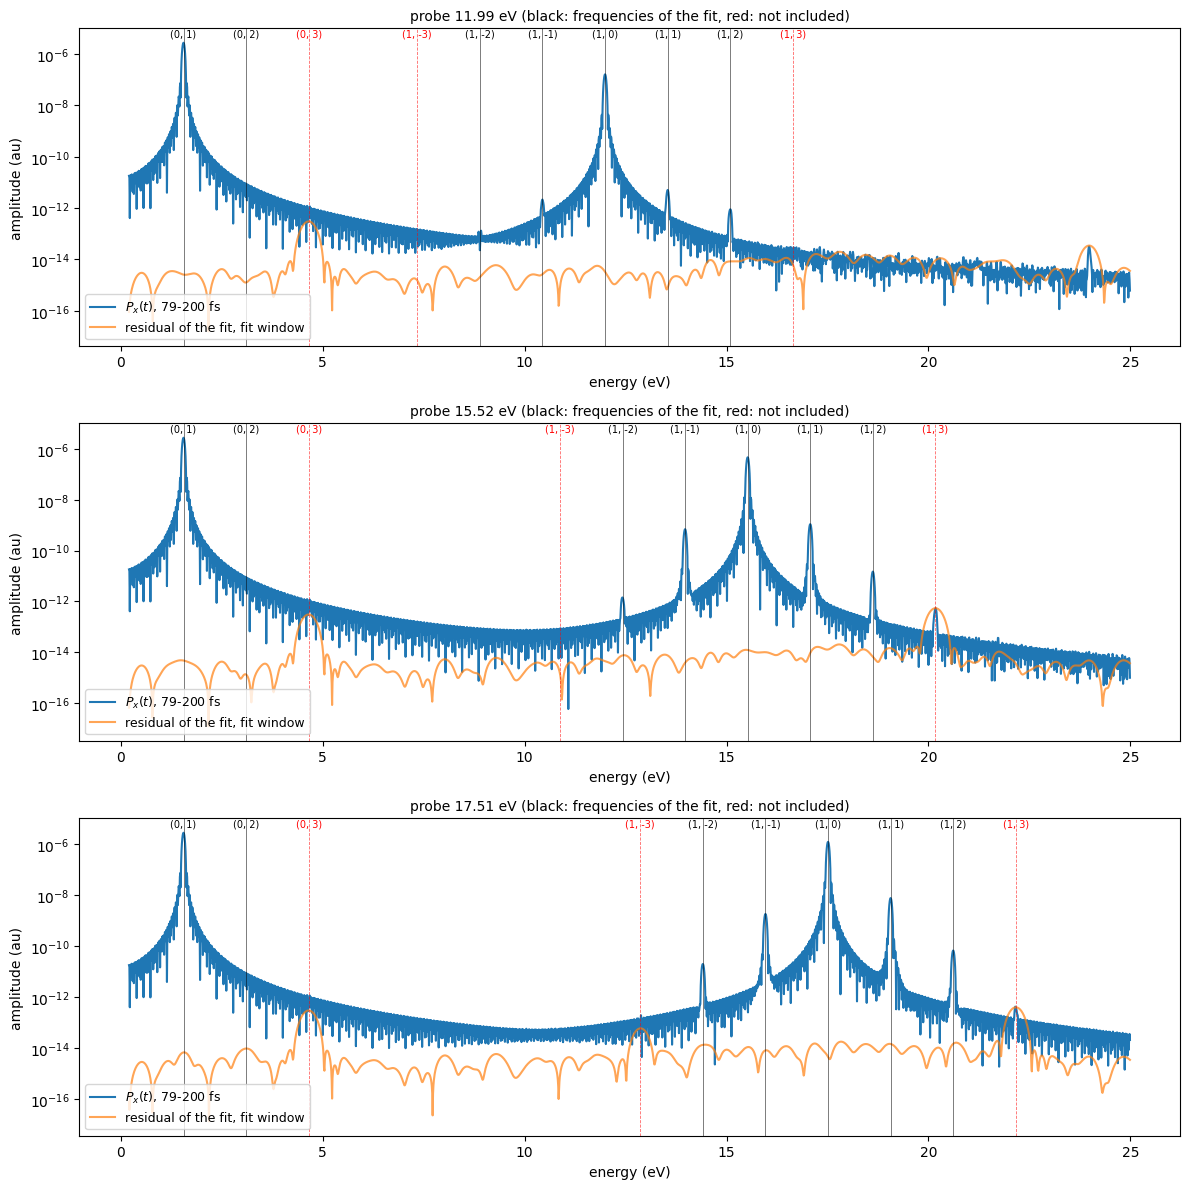

In [16]:
spectra = {}
for ifreq in ifreqs:
    t_long, p_long = time[i_deph:], pol_Pp[ifreq,0,i_deph:]
    res, B0, _ = freq_mix.perform_harmonic_analysis(ifreq)[0]
    iTstart, iTend = freq_mix.set_time_sampling(ifreq)
    t_fit, p_fit = time[iTstart:iTend], pol_Pp[ifreq,0,iTstart:iTend]
    resid = p_fit - eval_sum_frequencies(t_fit,res,B0)
    spectra[ifreq] = dict(raw=amplitude_spectrum(t_long,p_long,energies/Const.HaToeV),
                          resid=amplitude_spectrum(t_fit,resid,energies/Const.HaToeV),
                          fit=res, rms_resid=np.sqrt(np.mean(resid**2)))

fig,axes = plt.subplots(len(ifreqs),1,figsize=(12,4*len(ifreqs)))
for ax,ifreq in zip(axes,ifreqs):
    s = spectra[ifreq]
    ax.semilogy(energies,s['raw'],label='$P_x(t)$, 79-200 fs')
    ax.semilogy(energies,s['resid'],alpha=0.7,label='residual of the fit, fit window')
    Om12 = generate_frequencies(omega[ifreq],omega_P,max_order_E1=1,max_order_E2=2)
    Om13 = generate_frequencies(omega[ifreq],omega_P,max_order_E1=1,max_order_E2=3)
    for key,Om in Om13.items():
        fitted = key in Om12
        ax.axvline(Om*Const.HaToeV,color='k' if fitted else 'r',ls='-' if fitted else '--',lw=0.6,alpha=0.6)
        ax.text(Om*Const.HaToeV,ax.get_ylim()[1],str(key),fontsize=7,ha='center',va='top',color='k' if fitted else 'r')
    ax.set_title('probe %.2f eV (black: frequencies of the fit, red: not included)'%freqs[ifreq],fontsize=10)
    ax.set_xlabel('energy (eV)')
    ax.set_ylabel('amplitude (au)')
    ax.legend(loc='lower left',fontsize=9)
plt.tight_layout()

In [17]:
for ifreq in ifreqs:
    s = spectra[ifreq]
    print('probe %.2f eV  - rms of the residual of the fit: %.2e'%(freqs[ifreq],s['rms_resid']))
    print('   %-8s %10s %12s %12s'%('key','Omega (eV)','A fit','A spectrum'))
    Om13 = generate_frequencies(omega[ifreq],omega_P,max_order_E1=1,max_order_E2=3)
    for key,Om in Om13.items():
        A_spec = amplitude_spectrum(time[i_deph:],pol_Pp[ifreq,0,i_deph:],[Om])[0]
        A_fit = s['fit'][key]['A'] if key in s['fit'] else np.nan
        print('   %-8s %10.3f %12.3e %12.3e'%(str(key),Om*Const.HaToeV,A_fit,A_spec))

probe 11.99 eV  - rms of the residual of the fit: 2.20e-13
   key      Omega (eV)        A fit   A spectrum
   (1, 0)       11.990    1.616e-07    1.616e-07
   (0, 1)        1.550    2.744e-06    2.744e-06
   (0, 2)        3.100    8.823e-13    8.996e-12
   (0, 3)        4.650          nan    4.954e-13
   (1, 1)       13.540    4.947e-12    5.084e-12
   (1, -1)      10.440    2.061e-12    2.152e-12
   (1, 2)       15.090    9.333e-13    8.966e-13
   (1, -2)       8.890    8.710e-14    2.272e-14
   (1, 3)       16.640          nan    7.366e-15
   (1, -3)       7.340          nan    1.524e-13
probe 15.52 eV  - rms of the residual of the fit: 1.04e-12
   key      Omega (eV)        A fit   A spectrum
   (1, 0)       15.522    4.680e-07    4.680e-07
   (0, 1)        1.550    2.744e-06    2.744e-06
   (0, 2)        3.100    8.832e-13    9.002e-12
   (0, 3)        4.650          nan    4.943e-13
   (1, 1)       17.072    1.092e-09    1.091e-09
   (1, -1)      13.972    6.930e-10    6.920e-10


**Results of test 2.** The spectrum of the raw polarization, computed in a window of 120 fs independently of the fit,
shows well resolved peaks at $\omega\pm\omega_P$ for all the three probe frequencies, and their amplitudes coincide with
the fitted ones within a few per cent or better (e.g. at 15.52 eV: $1.092\cdot10^{-9}$ from the fit and
$1.091\cdot10^{-9}$ from the spectrum for $(1,1)$). The same holds for $(1,\pm2)$, except where they fall in the
background of the spectrum (e.g. $(1,-2)$ at 12 eV, $\sim10^{-13}$). The residual of the fit has an rms of
$10^{-13}-3\cdot10^{-12}$, three orders of magnitude below the $(1,\pm1)$ components, and its spectrum only shows the
tiny $(0,3)$ and $(1,3)$ harmonics of test 1. The size of the $(1,\pm1)$ peaks grows with the probe response (from
$\sim 5\cdot10^{-12}$ at 12 eV, below the gap, to $\sim 8\cdot10^{-9}$ at the 17.5 eV resonance), while no peak is visible
at $2\omega_P$ (the value of the $(0,2)$ row in the spectrum, $9\cdot10^{-12}$, is the tail of the large $\omega_P$ peak,
1.55 eV away; the fit gives $9\cdot10^{-13}$).

**Conclusions.** The harmonic analysis is correct: the components at $\omega\pm\omega_P$ are really present in the
polarization computed by `yambo_nl` in the P&p runs, with the amplitude given by the fit. Since they are forbidden by
the inversion symmetry of LiF, while the second order response of each field alone vanishes (pump SHG $\sim 3\cdot10^{-7}$,
probe SHG and rectification $\lesssim 2\cdot10^{-5}$), they have to be produced by the simulation of the two fields
together. Possible origins to be investigated:

- a numerical breaking of the inversion symmetry in the dynamics that shows up only when the probe is resonant (the
  terms follow the probe resonances), e.g. in the Berry phase polarization on the 8-point k strings or in the
  propagation of the two fields with INVINT;
- a genuine but unexpected bilinear term of the simulated model.

Tests that need new `yambo_nl` runs (to be decided): reverse the direction of the pump (`Field2_Dir` = -x; a bilinear
$E_pE_P$ term changes sign), halve the pump intensity (a term linear in $E_P$ halves), or repeat a few probe frequencies
with a denser k grid / smaller time step.

The inversion symmetry of the k sampling of the ground state (k grid, band energies and dipoles at $\mathbf{k}$ and
$-\mathbf{k}$) is checked at the beginning of `YamboNL_Analysis.ipynb`: the k sampling does not break the inversion
symmetry, so it is not the origin of the $(1,\pm1)$ terms.

#### Test 3: diagnostic runs (intensity scaling and time step)

The previous tests show that the components at $\omega\pm\omega_P$ are present in the polarization computed by
`yambo_nl`. To understand their origin we use the diagnostic runs of `YamboNL_Analysis.ipynb`: P&p simulations for the
5 probe frequencies 17.41-17.61 eV (indices 149-153 of the production grid, around the resonance where the $(1,\pm1)$
terms are largest), performed with the rebuilt yambo (Lumen 2.1.0):

- **reference**: the parameters of the production run ($E_p$, $E_P$, `NLstep` = 0.01 fs);
- **pump_int/4**: pump intensity / 4, i.e. $E_P/2$;
- **probe_int\*4**: probe intensity x 4, i.e. $2E_p$;
- **nlstep/2**: `NLstep` = 0.005 fs.

From the amplitudes $|P(\Omega)|$ of the fitted components we estimate the exponents of the scaling
$|P| \propto E_p^{a}E_P^{b}$:
$$
a = \log_2\frac{|P|_{\rm probe\_int*4}}{|P|_{\rm reference}}, \qquad
b = -\log_2\frac{|P|_{\rm pump\_int/4}}{|P|_{\rm reference}}
$$
A genuine second order response gives $a=b=1$ for the $(1,\pm1)$ components, while the physical terms must follow
their order: $a=1$, $b=2$ for $(1,\pm2)$ and $a=1$, $b=0$ for $(1,0)$, whose third order part scales as $|E_P|^2$.
The time step run tests the stability of all the keys w.r.t. the time integration.

In [18]:
diag_folders = {
    'reference'   : 'Pp-Ep_1e3-EP_1e6-PE_1.55-nlenrange_17.41294-17.66169-nlensteps_5-bands_3-6-damp_0.1-sin-nlstep_0.01',
    'pump_int/4'  : 'Pp-Ep_1e3-EP_2.5e5-PE_1.55-nlenrange_17.413-17.662-nlensteps_5-bands_3-6-damp_0.1-sin-nlstep_0.01',
    'probe_int*4' : 'Pp-Ep_4e3-EP_1e6-PE_1.55-nlenrange_17.41294-17.66169-nlensteps_5-bands_3-6-damp_0.1-sin-nlstep_0.01',
    'nlstep/2'    : 'Pp-Ep_1e3-EP_1e6-PE_1.55-nlenrange_17.41294-17.66169-nlensteps_5-bands_3-6-damp_0.1-sin-nlstep_0.005'}
diag = {}
for name,folder in diag_folders.items():
    data = P.YamboNLDBParser(os.path.join(run_dir,folder,'ndb.Nonlinear'),verbose=False)
    fm = O.Xn_frequency_mixing(data,X_order=(1,2),verbose=False)
    diag[name] = dict(data=data, fm=fm, chi=fm.compute_Xn()[0], Pw=fm.eval_Pw()[0],
                      Ep=data.Efield[0]['amplitude'], EP=data.Efield2[0]['amplitude'])
idx = np.arange(149,154)   # indices of the production grid
f_diag = diag['reference']['fm'].probe_freqs*Const.HaToeV
print('probe frequencies (eV)     :',f_diag.round(4))
print('production frequencies (eV):',freqs[idx].round(4))
for name,d in diag.items():
    print('%-12s E0 probe %.3e  E0 pump %.3e au'%(name,d['Ep'],d['EP']))

probe frequencies (eV)     : [17.4129 17.4627 17.5124 17.5622 17.6119]
production frequencies (eV): [17.4129 17.4627 17.5124 17.5622 17.6119]
reference    E0 probe 3.775e-06  E0 pump 1.194e-04 au
pump_int/4   E0 probe 3.775e-06  E0 pump 5.968e-05 au
probe_int*4  E0 probe 7.549e-06  E0 pump 1.194e-04 au
nlstep/2     E0 probe 3.775e-06  E0 pump 1.194e-04 au


**Reference run vs production run.** The two runs have the same parameters, but they are performed with different
builds of yambo (Lumen 2.1.0 with the setup redone vs Lumen 2.0.0): we compare the keys at the same probe frequencies.

In [19]:
keys = [(1,0),(1,1),(1,-1),(1,2),(1,-2)]
ref = diag['reference']['chi']
print('relative difference |chi_ref - chi_prod|/|chi_prod| at the 5 probe frequencies')
for key in keys:
    print('  %-8s'%str(key), (np.abs(ref[key]-chi_freqmix[key][idx])/np.abs(chi_freqmix[key][idx])).round(5))
d3_ref, d3_prod = ref[(1,0)]-chi1_sin[idx], chi_freqmix[(1,0)][idx]-chi1_sin[idx]
print('  %-8s'%'(1,0)-chi1', (np.abs(d3_ref-d3_prod)/np.abs(d3_prod)).round(5))

relative difference |chi_ref - chi_prod|/|chi_prod| at the 5 probe frequencies
  (1, 0)   [3.e-05 2.e-05 1.e-05 0.e+00 0.e+00]
  (1, 1)   [6.e-05 5.e-05 3.e-05 1.e-05 0.e+00]
  (1, -1)  [1.4e-04 7.0e-05 4.0e-05 1.0e-05 1.0e-05]
  (1, 2)   [3.7e-04 1.8e-04 8.0e-05 2.0e-05 4.0e-05]
  (1, -2)  [6.0e-05 7.0e-05 1.4e-04 1.5e-04 3.0e-04]
  (1,0)-chi1 [0.06736 0.06103 0.032   0.01216 0.00508]


The reference run reproduces the production run to $10^{-4}$ or better for all the keys, so the rebuilt yambo and the
new setup give the same dynamics and the diagnostic runs can be compared with the production ones. (The larger
differences of $\chi_{(1,0)}-\chi^{(1)}$ come from the $10^{-5}$ differences of $\chi_{(1,0)}$, amplified because the
third order part is $\sim10^{-3}$ of $\chi^{(1)}$; here $\chi^{(1)}$ is taken from the production probe-only run.)

**Scaling of the components with the field amplitudes.**

In [20]:
amp = lambda name,key : np.abs(diag[name]['Pw'][key])
ratio_Ep = diag['probe_int*4']['Ep']/diag['reference']['Ep']
ratio_EP = diag['pump_int/4']['EP']/diag['reference']['EP']
print('field ratios: E_p %.4f, E_P %.4f'%(ratio_Ep,ratio_EP))
print('%-8s %-36s %-36s'%('key','exponent a (probe)','exponent b (pump)'))
for key in keys:
    a = np.log(amp('probe_int*4',key)/amp('reference',key))/np.log(ratio_Ep)
    b = np.log(amp('pump_int/4',key)/amp('reference',key))/np.log(ratio_EP)
    print('%-8s %-36s %-36s'%(str(key),a.round(3),b.round(3)))
# third order part of (1,0): it must scale as |E_P|^2, so the difference between the reference and the pump_int/4 runs
# gives chi_(1,1,-1) (1-ratio_EP^2)|E_P|^2, to be compared with chi_(1,0)-chi1 of the reference run
x3_ref = (ref[(1,0)]-chi1_sin[idx])/(diag['reference']['EP']**2/4)
x3_diff = (ref[(1,0)]-diag['pump_int/4']['chi'][(1,0)])/((1-ratio_EP**2)*diag['reference']['EP']**2/4)
print('\nthird order term chi_(1,1,-1) from (reference - probe only) and from (reference - pump_int/4):')
print('  |x3| reference - probe only :',np.abs(x3_ref).round(1))
print('  |x3| reference - pump_int/4 :',np.abs(x3_diff).round(1))

field ratios: E_p 2.0000, E_P 0.5000
key      exponent a (probe)                   exponent b (pump)                   
(1, 0)   [1. 1. 1. 1. 1.]                     [-0. -0. -0.  0.  0.]               
(1, 1)   [1. 1. 1. 1. 1.]                     [1.002 0.999 0.999 0.999 1.   ]     
(1, -1)  [1. 1. 1. 1. 1.]                     [0.993 1.002 1.002 1.001 1.001]     
(1, 2)   [1. 1. 1. 1. 1.]                     [1.997 1.998 1.998 1.999 1.999]     
(1, -2)  [1.    1.    1.001 0.999 1.   ]      [1.996 1.999 1.999 2.003 2.   ]     

third order term chi_(1,1,-1) from (reference - probe only) and from (reference - pump_int/4):
  |x3| reference - probe only : [35903.8 31592.  30004.6 21564.9  9910.7]
  |x3| reference - pump_int/4 : [37515.9 32630.9 30522.3 21768.8  9856.9]


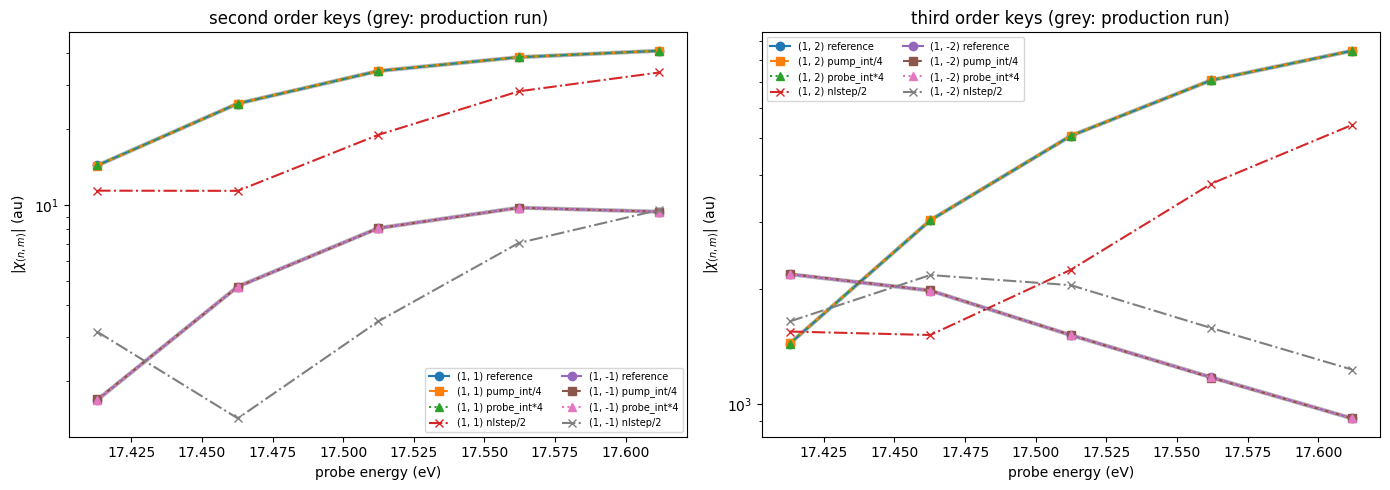

In [21]:
fig,axes = plt.subplots(1,2,figsize=(14,5))
styles = {'reference':'o-','pump_int/4':'s--','probe_int*4':'^:','nlstep/2':'x-.'}
for ax,keys_plot,title in zip(axes,[[(1,1),(1,-1)],[(1,2),(1,-2)]],['second order keys','third order keys']):
    for key in keys_plot:
        ax.semilogy(freqs[idx],np.abs(chi_freqmix[key][idx]),'k',lw=3,alpha=0.3)
        for name,d in diag.items():
            ax.semilogy(f_diag,np.abs(d['chi'][key]),styles[name],label='%s %s'%(str(key),name))
    ax.set_xlabel('probe energy (eV)')
    ax.set_ylabel(r'$|\chi_{(n,m)}|$ (au)')
    ax.set_title(title+' (grey: production run)')
    ax.legend(fontsize=7,ncol=2)
plt.tight_layout()

**The $(1,\pm1)$ components scale exactly as $E_pE_P$** ($a = 1.000$, $b = 1.00$ within $10^{-3}$ at all the
frequencies), as a genuine second order response. The physical keys behave as expected: $(1,\pm2)$ scale as
$E_pE_P^2$, $(1,0)$ is linear in the probe and its third order part scales as $|E_P|^2$ (the $\chi_{(1,1,-1)}$ extracted
from the reference - pump_int/4 difference agrees within a few per cent with the one extracted from the reference -
probe only difference). So the $(1,\pm1)$ terms are not numerical noise nor an artifact of the analysis: the simulated
system has a non vanishing second order susceptibility $\chi^{(2)}(\omega\pm\omega_P;\omega,\pm\omega_P)$.

**Time step.** Relative change of the keys when the time step is halved.

In [22]:
dt2 = diag['nlstep/2']['chi']
# (the third order part of (1,0) is not shown: chi1 itself changes with the time step, by much more than it)
for key in keys:
    print('  %-8s'%str(key), (np.abs(dt2[key]-ref[key])/np.abs(ref[key])).round(4))

  (1, 0)   [0.3543 0.415  0.439  0.3825 0.2729]
  (1, 1)   [0.2078 0.603  0.7775 0.8232 0.8623]
  (1, -1)  [0.9594 0.7273 0.8416 0.9358 0.9718]
  (1, 2)   [0.8368 0.723  1.0055 1.1898 1.4138]
  (1, -2)  [0.9531 1.0678 0.9752 0.7745 0.6992]


**Time step.** Halving the time step changes all the keys by tens of per cent, including $(1,0)$ which is essentially
$\chi^{(1)}$. This is the effect of the INVINT integrator found for the delta run: the transition energies are red
shifted by $\simeq (E\,dt)^2/12\hbar^2 \cdot E$, i.e. by $\sim 0.1$ eV at 17.5 eV with 0.01 fs and $\sim 0.025$ eV with
0.005 fs, and the 5 probe frequencies sit on a sharp resonance (width $\sim$ 0.1 eV), so a shift of a few hundredths of
eV changes the response at fixed frequency by tens of per cent. The ratios $|P(\omega\pm\omega_P)|/|P(\omega)|$ change by
factors 0.3-2 between the two time steps, as the ones of the physical $(1,\pm2)$ terms, so with these 5 frequencies the
time step test cannot separate a time integration artifact from the shift of the spectrum. A conclusive test needs a
frequency range wider than the shift of the resonances (or the comparison of the spectra after the energy mapping of
INVINT).

**Integrator.** The run `cranknic` has the same parameters of the reference run but uses the Crank-Nicolson integrator
(Hamiltonian recomputed at the midpoint of each step) instead of INVINT (Hamiltonian at the beginning of the step). For
the static part of $H$ the two schemes have the same phase error, so the resonances are not shifted. INVINT however
uses the field at the beginning of the step, i.e. with a delay of $dt/2$ w.r.t. CRANKNIC: this rotates the phase of a
component at frequency $\Omega$ by $\simeq \Omega\,dt/2$ ($\hbar=1$), which changes the complex $\chi$ by about the same
relative amount but not its modulus. We compare both the complex keys and their moduli.

In [23]:
folder_cn = 'Pp-Ep_1e3-EP_1e6-PE_1.55-nlenrange_17.413-17.662-nlensteps_5-bands_3-6-damp_0.1-sin-nlstep_0.01-CN'
data_cn = P.YamboNLDBParser(os.path.join(run_dir,folder_cn,'ndb.Nonlinear'),verbose=False)
fm_cn = O.Xn_frequency_mixing(data_cn,X_order=(1,2),verbose=False)
diag['cranknic'] = dict(data=data_cn, fm=fm_cn, chi=fm_cn.compute_Xn()[0], Pw=fm_cn.eval_Pw()[0],
                        Ep=data_cn.Efield[0]['amplitude'], EP=data_cn.Efield2[0]['amplitude'])
cn = diag['cranknic']['chi']
dt_au = 0.01*Const.FsToAu
omega_P_diag = diag['reference']['fm'].pump_freq
omega_diag = diag['reference']['fm'].probe_freqs
print('%-8s %-40s %-40s %s'%('key','|chi_CN - chi_INV|/|chi_INV|','| |chi_CN|/|chi_INV| - 1 |','Omega*dt/2'))
for key in [(1,0),(1,1),(1,-1),(1,2),(1,-2),(0,1),(0,2)]:
    Om = np.abs(key[0]*omega_diag + key[1]*omega_P_diag)
    print('%-8s %-40s %-40s %s'%(str(key),(np.abs(cn[key]-ref[key])/np.abs(ref[key])).round(4),
          np.abs(np.abs(cn[key])/np.abs(ref[key])-1).round(4),(Om*dt_au/2).round(4)))
for key in [(1,1),(1,-1)]:
    print('|chi_%s||E_P|/|chi_(1,0)|  INVINT: %s  CRANKNIC: %s'%(str(key),
          (np.abs(ref[key])*abs_EP/np.abs(ref[(1,0)])).round(5),(np.abs(cn[key])*abs_EP/np.abs(cn[(1,0)])).round(5)))

key      |chi_CN - chi_INV|/|chi_INV|             | |chi_CN|/|chi_INV| - 1 |               Omega*dt/2
(1, 0)   [0.062  0.0605 0.0909 0.1145 0.1092]     [0.0187 0.0179 0.0392 0.0374 0.0229]     [0.1323 0.1327 0.133  0.1334 0.1338]
(1, 1)   [0.3049 0.164  0.123  0.1237 0.1176]     [0.183  0.1101 0.0401 0.0169 0.0104]     [0.144  0.1444 0.1448 0.1452 0.1456]
(1, -1)  [0.595  0.2079 0.0885 0.0764 0.1196]     [0.3456 0.187  0.0671 0.0084 0.0407]     [0.1205 0.1209 0.1213 0.1216 0.122 ]
(1, 2)   [0.5445 0.2992 0.2045 0.1336 0.083 ]     [0.2229 0.1724 0.0937 0.0497 0.0361]     [0.1558 0.1562 0.1566 0.157  0.1573]
(1, -2)  [0.1258 0.1971 0.2525 0.2743 0.2935]     [0.0096 0.0714 0.0718 0.0634 0.0679]     [0.1087 0.1091 0.1095 0.1099 0.1102]
(0, 1)   [0.0118 0.0118 0.0118 0.0118 0.0118]     [0. 0. 0. 0. 0.]                         [0.0118 0.0118 0.0118 0.0118 0.0118]
(0, 2)   [0.0339 0.0367 0.0398 0.0391 0.0395]     [0.0083 0.0031 0.0049 0.005  0.0045]     [0.0235 0.0235 0.0235 0.0235 0.0235]
|c

**Results of the integrator test.** The linear response of the pump $(0,1)$ shows the expected behaviour: its modulus
does not change and the complex value changes exactly by $\omega_P dt/2 = 0.0118$, i.e. INVINT and CRANKNIC differ by
the phase delay of the field. The other keys change by a similar amount in the complex value (the phase delay plus the
different treatment of the state dependent coupling) and by a few per cent up to $\sim 20-35\%$ in modulus, the largest
changes being at the lowest probe frequencies, where the response is weaker and steeper. These changes are of the same
size for the $(1,\pm1)$ terms and for the physical third order terms $(1,\pm2)$. The relative size of the second
order terms is the same with the two integrators: $|\chi_{(1,1)}||E_P|/|\chi_{(1,0)}|$ goes from $2.5\cdot10^{-3}$ to
$10^{-2}$ across the 5 frequencies with INVINT and from $3.0\cdot10^{-3}$ to $10^{-2}$ with CRANKNIC (similarly for
$(1,-1)$). So the time integration is not the origin of the $(1,\pm1)$ terms: they are present with the same size with
a second order integrator, as expected from the fact that an integrator cannot break the inversion symmetry if all the
terms of the dynamics respect it.

**k grid.** The reference run is repeated on the $12\times12\times12$ grid (SAVE of D. Sangalli with the same lattice,
bands and symmetries, setup redone with Lumen 2.1.0; 12 points per Berry phase string instead of 8). If the
$(1,\pm1)$ terms come from the k discretization of the coupling with the field, their size relative to the linear
response, $|\chi_{(1,\pm1)}||E_P|/|\chi_{(1,0)}|$, must decrease. The third order terms
$|\chi_{(1,\pm2)}||E_P|^2/|\chi_{(1,0)}|$ are shown as a control.

In [24]:
run_dir_kx12 = 'kx12_nb100_NoTr_E100'
data_kx12 = P.YamboNLDBParser(os.path.join(run_dir_kx12,diag_folders['reference'],'ndb.Nonlinear'),verbose=False)
fm_kx12 = O.Xn_frequency_mixing(data_kx12,X_order=(1,2),verbose=False)
diag['kx12'] = dict(data=data_kx12, fm=fm_kx12, chi=fm_kx12.compute_Xn()[0], Pw=fm_kx12.eval_Pw()[0],
                    Ep=data_kx12.Efield[0]['amplitude'], EP=data_kx12.Efield2[0]['amplitude'])
kx12 = diag['kx12']['chi']
print('|chi_(1,0)|  kx8 :',np.abs(ref[(1,0)]).round(4))
print('|chi_(1,0)|  kx12:',np.abs(kx12[(1,0)]).round(4))
rel_size = lambda chi,key : np.abs(chi[key])*abs_EP**abs(key[1])/np.abs(chi[(1,0)])
print('\n%-8s %-38s %-38s %s'%('key','relative size kx8','relative size kx12','ratio kx12/kx8'))
for key in [(1,1),(1,-1),(1,2),(1,-2)]:
    r8, r12 = rel_size(ref,key), rel_size(kx12,key)
    print('%-8s %-38s %-38s %s'%(str(key),np.array2string(r8,precision=6),np.array2string(r12,precision=6),(r12/r8).round(3)))

|chi_(1,0)|  kx8 : [0.3363 0.3501 0.3199 0.2765 0.2475]
|chi_(1,0)|  kx12: [0.1688 0.1512 0.14   0.1464 0.15  ]

key      relative size kx8                      relative size kx12                     ratio kx12/kx8
(1, 1)   [0.002545 0.004301 0.006336 0.008314 0.009852] [0.002332 0.002098 0.002026 0.001996 0.00188 ] [0.917 0.488 0.32  0.24  0.191]
(1, -1)  [0.0003   0.00081  0.00151  0.002106 0.002267] [0.001003 0.001028 0.001104 0.001039 0.000906] [3.35  1.269 0.731 0.493 0.4  ]
(1, 2)   [1.525767e-05 3.090199e-05 5.633537e-05 9.125050e-05 1.217450e-04] [5.604101e-05 7.017394e-05 8.077326e-05 8.317785e-05 8.130322e-05] [3.673 2.271 1.434 0.912 0.668]
(1, -2)  [2.320010e-05 2.018980e-05 1.687489e-05 1.512088e-05 1.319150e-05] [1.122869e-05 1.149263e-05 1.223746e-05 1.128690e-05 9.361102e-06] [0.484 0.569 0.725 0.746 0.71 ]


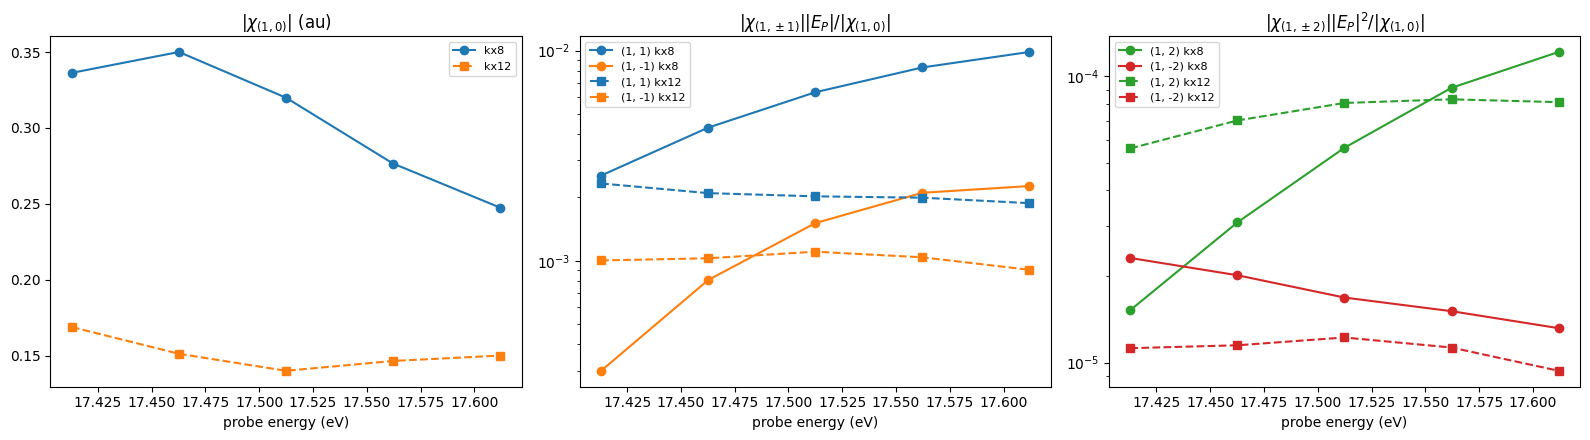

In [25]:
fig,axes = plt.subplots(1,3,figsize=(16,4.5))
for chi,lab,st in [(ref,'kx8','o-'),(kx12,'kx12','s--')]:
    axes[0].plot(f_diag,np.abs(chi[(1,0)]),st,label=lab)
    for key,c in [((1,1),'C0'),((1,-1),'C1')]:
        axes[1].semilogy(f_diag,rel_size(chi,key),st,color=c,label='%s %s'%(str(key),lab))
    for key,c in [((1,2),'C2'),((1,-2),'C3')]:
        axes[2].semilogy(f_diag,rel_size(chi,key),st,color=c,label='%s %s'%(str(key),lab))
axes[0].set_title(r'$|\chi_{(1,0)}|$ (au)')
axes[1].set_title(r'$|\chi_{(1,\pm1)}||E_P|/|\chi_{(1,0)}|$')
axes[2].set_title(r'$|\chi_{(1,\pm2)}||E_P|^2/|\chi_{(1,0)}|$')
for ax in axes:
    ax.set_xlabel('probe energy (eV)')
    ax.legend(fontsize=8)
plt.tight_layout()

**Results of the k grid test.** The linear response itself is not converged on the kx8 grid in this energy range:
$|\chi_{(1,0)}|\simeq|\chi^{(1)}|$ halves going from kx8 to kx12 at the 5 probe frequencies (the 17.5 eV peak of the kx8
spectrum is a feature of the coarse sampling, with a damping of 0.1 eV). The relative size of the $(1,\pm1)$ terms
changes from $2.5\cdot10^{-3}-10^{-2}$ (kx8) to $\simeq 2\cdot10^{-3}$ (kx12), i.e. by factors 0.2-0.9 for $(1,1)$ and
0.4-3 for $(1,-1)$, but the physical third order terms change by similar factors (0.5-3.7). With 5 frequencies on a
structure that is not converged with the k sampling, the change of the spectrum dominates and the test cannot tell if
the $(1,\pm1)$ terms decrease with $\Delta k$. Note that on the kx12 grid the $(1,\pm1)$ terms are still $\sim 20-100$
times larger than the third order ones: they do not disappear.

A conclusive test needs the comparison of the two grids on a wide energy range (e.g. the whole 10-20 eV window with a
coarser frequency step), so that quantities averaged over the spectrum can be compared, or a third, denser grid
(kx16) to see a trend. In any case the result shows that the k convergence of the spectrum (kx8 vs kx12) must be
considered also for the comparison with the RT results of D. Sangalli, that are computed on the kx16 grid.

**Conclusions of the diagnostics.** The $(1,\pm1)$ terms are a genuine second order (bilinear $E_pE_P$) response of the
system simulated by `yambo_nl`, while LiF is centrosymmetric and the k sampling of the ground state is inversion
symmetric. A consistent picture is a small breaking of the inversion symmetry in the dynamics, the same for all the
second order terms, that becomes visible only where the response is resonant: $\omega\pm\omega_P$ falls in the
absorption region (15-20 eV), while the second harmonic of the pump ($2\omega_P$ = 3.1 eV) is far below the gap and the
one of the probe ($2\omega$ = 20-40 eV) is mostly outside the transitions between the bands 3-6. Per unit field, the
$\chi^{(2)}$ of the probe second harmonic is not zero either (it is only $\sim20$ times smaller than the mixing one).

The time integration is excluded: the $(1,\pm1)$ terms have the same size with the INVINT and the CRANKNIC
integrators. The remaining candidate is the spatial discretization, in particular the discretization of the coupling
with the field in the Berry phase approach, which is computed from
the overlaps between neighbouring k points on the 8-point strings: a finite difference formula that is not symmetric
under $\mathbf{k}\to-\mathbf{k}$ breaks the inversion at order $\Delta k$. A first test with the kx12 grid (5 frequencies) is not conclusive, because the
spectrum itself changes strongly with the k grid at these frequencies (see above). It can be tested by repeating
the reference run on a denser k grid over a wide energy range (the $(1,\pm1)$ terms should decrease with $\Delta k$, while the physical keys converge), e.g.
with the kx16 SAVE used by D. Sangalli for the RT runs. The RT transient absorption of D. Sangalli is computed with the
same code, so the same term, linear in $E_P$, could appear there as an oscillation of the transient spectrum with period
$2\pi/\omega_P$ = 2.67 fs as a function of the delay.

## Convergence of the linear response with the k grid

The diagnostics show that $|\chi^{(1)}|$ changes by a factor 2 around 17.5 eV between the kx8 and kx12 grids. We
compare the linear response computed with the delta runs on the kx8, kx12 and kx16 grids (same parameters: bands 3-6,
`NLstep` = 0.01 fs, 100 fs, no damping, see `YamboNL_Analysis.ipynb`). As for the kx8 run, a Lorentzian damping
$\eta$ = 0.1 eV (the damping of the sine runs) is applied in the FT. The grids whose delta run is not available are
skipped.

In [26]:
delta_dirs = {'kx8':'kx8_nb100_NoTr_E100', 'kx12':'kx12_nb100_NoTr_E100', 'kx16':'kx16_nb100_NoTr_E100'}
eps_k, chi1_k = {}, {}
for grid,folder in delta_dirs.items():
    file = os.path.join(folder,'lresponse-bands_3-6-delta','ndb.Nonlinear')
    if not os.path.isfile(file):
        print('%-5s delta run not available'%grid)
        continue
    d = P.YamboNLDBParser(file,verbose=False)
    t = np.array(d.IO_TIME_points)
    en, eps = O.Linear_Response(t,d.Polarization[0],d.Efield[0],eta=eta)
    eps_k[grid] = (en,eps)
    chi1_k[grid] = (en,(eps-1)/(4*np.pi))
    print('%-5s simulation time %.1f fs, %d time steps, NaN in the polarization: %s'%(
          grid,t[-1]/Const.FsToAu,len(t),np.isnan(d.Polarization[0]).any()))
grids = list(chi1_k.keys())

kx8   simulation time 100.0 fs, 10001 time steps, NaN in the polarization: False
kx12  simulation time 100.0 fs, 10001 time steps, NaN in the polarization: False
kx16  simulation time 100.0 fs, 10001 time steps, NaN in the polarization: False


Absorption spectrum $\mathrm{Im}\,\epsilon(\omega)$ on a wide energy range (the vertical line is the quasi-particle
gap, 14.80 eV, of the IPA calculation with the scissor of 6 eV) and real and imaginary parts of $\chi^{(1)}$ in the
10-20 eV window of the probe.

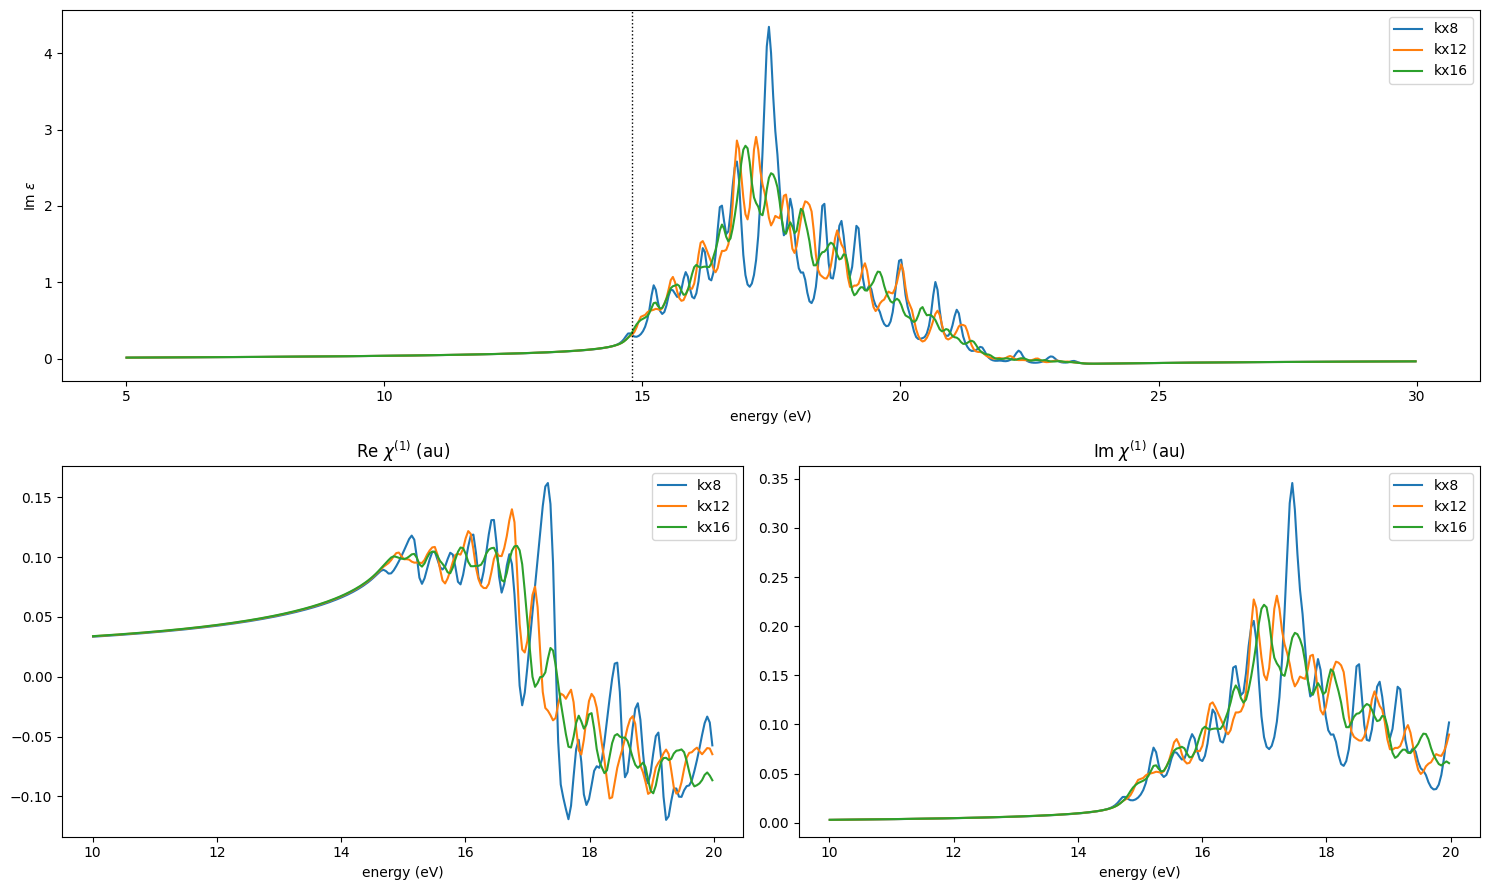

In [27]:
fig = plt.figure(figsize=(15,9))
ax = fig.add_subplot(2,1,1)
for grid in grids:
    en,eps = eps_k[grid]
    sel = (en > 5) & (en < 30)
    ax.plot(en[sel],eps[sel].imag,label=grid)
ax.axvline(14.80,color='k',ls=':',lw=1)
ax.set_xlabel('energy (eV)')
ax.set_ylabel(r'Im $\epsilon$')
ax.legend()
for i,(part,lab) in enumerate([(np.real,'Re'),(np.imag,'Im')]):
    ax = fig.add_subplot(2,2,3+i)
    for grid in grids:
        en,chi = chi1_k[grid]
        sel = (en > 10) & (en < 20)
        ax.plot(en[sel],part(chi[sel]),label=grid)
    ax.set_xlabel('energy (eV)')
    ax.set_title(r'%s $\chi^{(1)}$ (au)'%lab)
    ax.legend()
plt.tight_layout()

Relative difference between the grids in the 10-20 eV window, $|\chi^{(1)}_a-\chi^{(1)}_b|/|\chi^{(1)}_b|$, with the
densest available grid as reference $b$, and integrated quantities: the spectral weight $\int \mathrm{Im}\,\epsilon\,
d\omega$ in 10-20 eV and the static limit $\epsilon(\omega\to0)$ (both are expected to converge faster than the
structures of the spectrum).

kx8 vs kx16 (10-20 eV): mean relative difference 0.191, max 1.071
kx12 vs kx16 (10-20 eV): mean relative difference 0.112, max 0.480

kx8   spectral weight int Im eps (10-20 eV) = 7.201 eV   Re eps(0.5 eV) = 1.2867
kx12  spectral weight int Im eps (10-20 eV) = 7.302 eV   Re eps(0.5 eV) = 1.2890
kx16  spectral weight int Im eps (10-20 eV) = 7.357 eV   Re eps(0.5 eV) = 1.2900


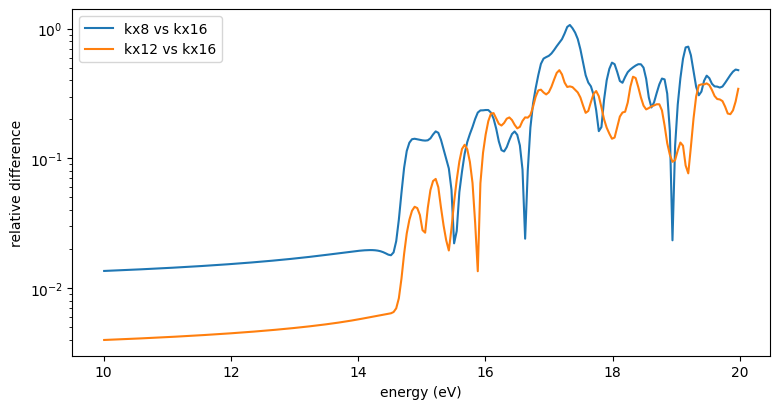

In [28]:
ref_grid = grids[-1]
en_ref,chi_ref = chi1_k[ref_grid]
sel = (en_ref > 10) & (en_ref < 20)
plt.figure(figsize=(9,4.5))
for grid in grids[:-1]:
    en,chi = chi1_k[grid]
    chi_i = np.interp(en_ref[sel],en,chi.real) + 1j*np.interp(en_ref[sel],en,chi.imag)
    rel = np.abs(chi_i-chi_ref[sel])/np.abs(chi_ref[sel])
    plt.semilogy(en_ref[sel],rel,label='%s vs %s'%(grid,ref_grid))
    print('%s vs %s (10-20 eV): mean relative difference %.3f, max %.3f'%(grid,ref_grid,rel.mean(),rel.max()))
plt.xlabel('energy (eV)')
plt.ylabel('relative difference')
plt.legend()
print()
for grid in grids:
    en,eps = eps_k[grid]
    s = (en > 10) & (en < 20)
    i0 = np.argmin(np.abs(en-0.5))
    print('%-5s spectral weight int Im eps (10-20 eV) = %.3f eV   Re eps(0.5 eV) = %.4f'%(grid,np.trapezoid(eps[s].imag,en[s]),eps[i0].real))

Consistency check on the kx12 grid: the linear response from the delta run is compared with the key $(1,0)$ of the
reference P&p run on the same grid (5 probe frequencies around 17.5 eV), which also contains the third order term
($\sim10^{-3}$ of $\chi^{(1)}$).

In [29]:
if 'kx12' in chi1_k:
    en,chi = chi1_k['kx12']
    chi_d = np.interp(f_diag,en,chi.real) + 1j*np.interp(f_diag,en,chi.imag)
    print('|chi1| delta kx12     :',np.abs(chi_d).round(4))
    print('|chi_(1,0)| P&p kx12  :',np.abs(diag['kx12']['chi'][(1,0)]).round(4))
    print('relative difference   :',(np.abs(chi_d-diag['kx12']['chi'][(1,0)])/np.abs(chi_d)).round(4))

|chi1| delta kx12     : [0.1643 0.1478 0.142  0.1477 0.1486]
|chi_(1,0)| P&p kx12  : [0.1688 0.1512 0.14   0.1464 0.15  ]
relative difference   : [0.0279 0.0326 0.0233 0.0142 0.0096]


**Results with a broadening of 0.1 eV.** Below the gap the three grids agree within $\sim1\%$, and the integrated
quantities are converged: the spectral weight $\int\mathrm{Im}\,\epsilon\,d\omega$ in 10-20 eV is 7.20, 7.30 and
7.36 eV and $\epsilon(0)$ is 1.2867, 1.2890 and 1.2900 for kx8, kx12 and kx16. Above the gap the structures of the
spectrum are not converged: w.r.t. kx16 the mean (max) relative difference in 10-20 eV is 19% (107%) for kx8 and 11%
(48%) for kx12. The strong peak at 17.5 eV of the kx8 spectrum is an artifact of the coarse sampling (on the denser
grids the spectral weight is spread over two peaks at $\simeq$ 16.9 and 17.5 eV), and the oscillations with a period
of a few tenths of eV are still present on the kx12 and kx16 grids: with $\eta$ = 0.1 eV none of the grids gives a
converged spectrum. The linear response of the kx12 delta run agrees with the key $(1,0)$ of the kx12 P&p run within
1-3%.

### Comparison of the grids with a broadening of 0.3 eV

The new sine and frequency mixing runs are planned with a damping of 0.3 eV (see `YamboNL_Analysis.ipynb`), so we
compare the linear response of the three grids with $\eta$ = 0.3 eV, and we summarize the differences between the
grids as a function of the broadening, in the 10-20 eV window of the analysis and in the absorption band (15-23 eV).

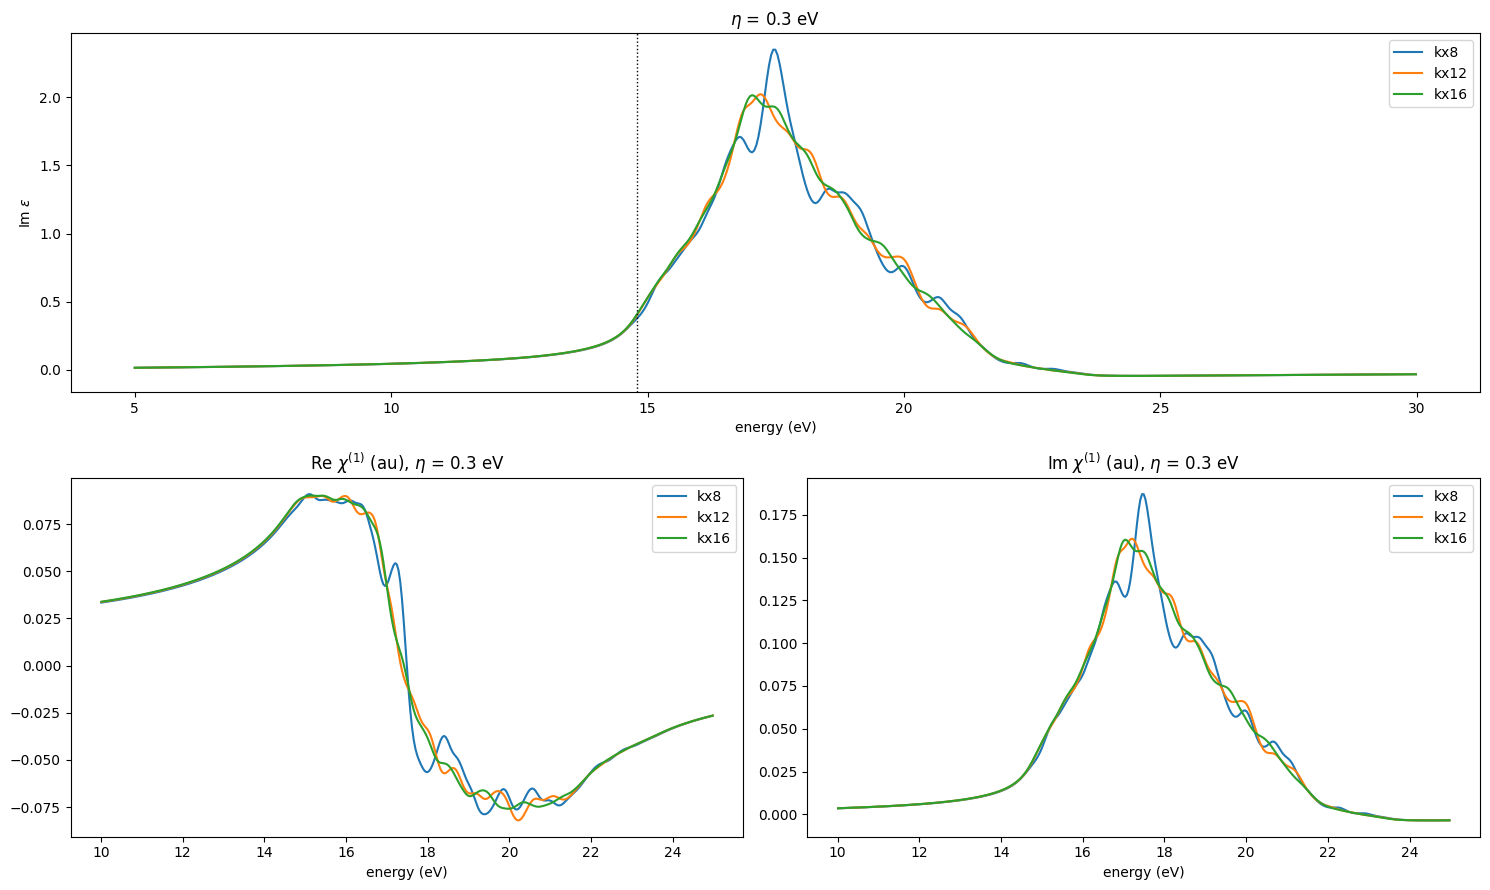

In [30]:
eta_cmp = 0.3
eps_k3, chi1_k3 = {}, {}
for grid,folder in delta_dirs.items():
    if grid not in chi1_k: continue
    d = P.YamboNLDBParser(os.path.join(folder,'lresponse-bands_3-6-delta','ndb.Nonlinear'),verbose=False)
    en, eps = O.Linear_Response(np.array(d.IO_TIME_points),d.Polarization[0],d.Efield[0],eta=eta_cmp)
    eps_k3[grid], chi1_k3[grid] = (en,eps), (en,(eps-1)/(4*np.pi))

fig = plt.figure(figsize=(15,9))
ax = fig.add_subplot(2,1,1)
for grid in grids:
    en,eps = eps_k3[grid]
    sel = (en > 5) & (en < 30)
    ax.plot(en[sel],eps[sel].imag,label=grid)
ax.axvline(14.80,color='k',ls=':',lw=1)
ax.set_xlabel('energy (eV)')
ax.set_ylabel(r'Im $\epsilon$')
ax.set_title(r'$\eta$ = %.1f eV'%eta_cmp)
ax.legend()
for i,(part,lab) in enumerate([(np.real,'Re'),(np.imag,'Im')]):
    ax = fig.add_subplot(2,2,3+i)
    for grid in grids:
        en,chi = chi1_k3[grid]
        sel = (en > 10) & (en < 25)
        ax.plot(en[sel],part(chi[sel]),label=grid)
    ax.set_xlabel('energy (eV)')
    ax.set_title(r'%s $\chi^{(1)}$ (au), $\eta$ = %.1f eV'%(lab,eta_cmp))
    ax.legend()
plt.tight_layout()

In [31]:
# relative differences w.r.t. the densest grid as a function of the broadening
data_k = {grid: P.YamboNLDBParser(os.path.join(delta_dirs[grid],'lresponse-bands_3-6-delta','ndb.Nonlinear'),verbose=False)
          for grid in grids}
windows = {'10-20 eV':(10,20), '15-23 eV':(15,23)}
print('relative difference |chi1_grid - chi1_%s|/|chi1_%s| (mean / max)'%(ref_grid,ref_grid))
print('%-8s %-6s'%('eta(eV)','grid') + ''.join('%-22s'%w for w in windows))
for eta_s in [0.1,0.2,0.3,0.6]:
    chis = {}
    for grid,d in data_k.items():
        en, eps = O.Linear_Response(np.array(d.IO_TIME_points),d.Polarization[0],d.Efield[0],eta=eta_s)
        chis[grid] = (en,(eps-1)/(4*np.pi))
    en_r,c_r = chis[ref_grid]
    for grid in grids[:-1]:
        en,c = chis[grid]
        line = '%-8.1f %-6s'%(eta_s,grid)
        for lo,hi in windows.values():
            s = (en_r > lo) & (en_r < hi)
            ci = np.interp(en_r[s],en,c.real) + 1j*np.interp(en_r[s],en,c.imag)
            r = np.abs(ci-c_r[s])/np.abs(c_r[s])
            line += '%-22s'%('%.3f / %.3f'%(r.mean(),r.max()))
        print(line)

relative difference |chi1_grid - chi1_kx16|/|chi1_kx16| (mean / max)
eta(eV)  grid  10-20 eV              15-23 eV              
0.1      kx8   0.191 / 1.071         0.294 / 1.071         
0.1      kx12  0.112 / 0.480         0.191 / 0.480         
0.2      kx8   0.097 / 0.484         0.139 / 0.484         
0.2      kx12  0.041 / 0.175         0.073 / 0.199         
0.3      kx8   0.062 / 0.264         0.082 / 0.264         
0.3      kx12  0.020 / 0.097         0.035 / 0.102         
0.6      kx8   0.026 / 0.069         0.031 / 0.069         
0.6      kx12  0.007 / 0.020         0.009 / 0.020         


**Results with a broadening of 0.3 eV and choice of the grid.** The convergence improves quickly with the broadening.
With $\eta$ = 0.3 eV the kx12 spectrum differs from the kx16 one by 2% on average (10% at most) in 10-20 eV and by 3.5%
(10%) in the absorption band, while kx8 still differs by 6-8% on average and by 26% at most (the peak at 17.5 eV). With
$\eta$ = 0.6 eV also kx8 is converged within a few per cent (kx12 within 2%). So for the sine and frequency mixing runs
with a damping of 0.3 eV the **kx12 grid** is adequate: the residual differences w.r.t. kx16 are of the order of the
accuracy of the a posteriori broadening, and they decrease further when the broadening is increased.

## Additional broadening on the probe frequency grid

With a damping of 0.1 eV the linear response is not converged with the k grid above the gap, while with a larger
broadening (e.g. the 0.6 eV smoothing of the RT spectra of D. Sangalli) the kx8 and kx12 spectra agree. For the delta
run the broadening is a post-processing parameter (the factor $e^{-\eta t}$ in the FT), while in the sine and P&p runs
the damping $\gamma$ is the dephasing used in the dynamics. The amplitude and phase of the harmonic fit of a single
run do not contain the resonances of the system (the free oscillations at the transition energies have been damped
before the fit window): the resonances are in the dependence of $\chi$ on the frequency of the field. A larger
broadening can still be obtained a posteriori from the frequency dependence:

- a causal response $\chi(\omega)$ is analytic in the upper half plane, and increasing its broadening by $\Delta$
  ($\gamma\to\gamma+\Delta$ in the resonant denominators) means evaluating $\chi(\omega+i\Delta)$, which is exactly the
  Lorentzian convolution on the real axis
  $$
  \chi_\Delta(\omega) = \frac{1}{\pi}\int d\omega' \frac{\Delta}{(\omega-\omega')^2+\Delta^2}\chi(\omega') = \chi(\omega+i\Delta)
  $$
- the keys $(1,m)$ of the frequency mixing are linear in the probe: they are the linear response to the probe of the
  system driven by the pump, so they are analytic in the probe frequency (at fixed $\omega_P$). The convolution on the
  probe grid adds $\Delta$ to all the denominators that contain the probe frequency (the coherences created by the
  probe), while the ones that contain only the pump frequency are not changed. This is not identical to a dynamics with
  a larger dephasing, but it is the analogue of the smoothing applied in time to the probe induced signal in the RT
  spectra;
- the higher harmonics of a single field ($\chi_n(n\omega;\omega,\dots,\omega)$, $n\ge2$) are not broadened uniformly
  ($\omega\to\omega+i\Delta$ adds $k\Delta$ to the $k$-th denominator), so the method applies only to $\chi^{(1)}$ and
  to the keys $(1,m)$.

The convolution needs a frequency grid with a step much smaller than $\Delta$ and it is affected by the finite window:
near the edges part of the Lorentzian is missing (a fraction $\sim\Delta/\pi d$ at a distance $d$ from the edge). The
prototype below renormalizes the kernel on the available window (option `renormalize`), which is exact for a constant
$\chi$ and reduces the edge error for a smooth one.

In [32]:
def lorentzian_broadening(freqs, chi, delta, renormalize=True):
    # chi_delta(w) = 1/pi int dw' delta/((w-w')^2+delta^2) chi(w') = chi(w+i*delta) for a causal response.
    # freqs: uniform grid (same units of delta), chi: array (or list of arrays along the last axis) on the grid
    w = np.asarray(freqs)
    kernel = delta/np.pi/((w[:,None]-w[None,:])**2 + delta**2)
    weights = np.full(len(w),w[1]-w[0])
    weights[0] = weights[-1] = (w[1]-w[0])/2   # trapezoidal rule
    kernel = kernel*weights[None,:]
    if renormalize:
        kernel /= kernel.sum(axis=1)[:,None]
    return np.asarray(chi) @ kernel.T

### Validation on the anharmonic oscillator

We use the classical anharmonic oscillator of MPPI ($\omega_0$ = 0.5 Ha, $\gamma$ = 0.01 Ha), whose susceptibilities
are known analytically also at complex frequency. The P&p simulations (probe 0.30-0.75 Ha, pump $\omega_P$ = 0.05 Ha)
are analyzed with `Xn_frequency_mixing` as the yambo_nl runs; the keys are broadened by $\Delta$ = 0.01 Ha and compared
with the exact $\chi(\omega+i\Delta)$ and with the exact $\chi$ of an oscillator with damping $\gamma+\Delta$:

- oscillator with a quadratic anharmonicity ($a$ = 0.1): $\chi^{(1)}$ and $\chi_{(1,\pm1)} = 2\chi^{(2)}(\omega\pm\omega_P;\omega,\pm\omega_P)$;
- oscillator with a cubic anharmonicity ($b$ = 0.1): $\chi_{(1,\pm2)} = 3\chi^{(3)}(\omega\pm2\omega_P;\omega,\pm\omega_P,\pm\omega_P)$
  and the third order part of $(1,0)$, $6\chi^{(3)}(\omega;\omega,\omega_P,-\omega_P)$.

In [33]:
from mppi.Models.AnharmonicOscillator import AnharmonicOscillator

gamma_osc, delta_osc = 0.01, 0.01                       # Ha
w_osc = np.linspace(0.30,0.75,136)                       # probe grid (Ha), step 0.0033 Ha
wP_osc, t0_osc = 0.05, 5.
time_osc = np.arange(0,3000,0.25)
osc_a = AnharmonicOscillator(omega0=0.5,gamma=gamma_osc,a=0.1)
osc_b = AnharmonicOscillator(omega0=0.5,gamma=gamma_osc,b=0.1)
EP_a, EP_b = 1e-4, 2e-3
data_a = osc_a.sine_response(time_osc,w_osc,amplitude=1e-5,initial_time=t0_osc,
                             pump={'frequency':wP_osc,'amplitude':EP_a,'initial_time':t0_osc},substeps=4)
data_b = osc_b.sine_response(time_osc,w_osc,amplitude=1e-5,initial_time=t0_osc,
                             pump={'frequency':wP_osc,'amplitude':EP_b,'initial_time':t0_osc},substeps=4)
probe_b = osc_b.sine_response(time_osc,w_osc,amplitude=1e-5,initial_time=t0_osc,substeps=4)
chi_a = O.Xn_frequency_mixing(data_a,X_order=(1,1),verbose=False).compute_Xn()[0]
chi_b = O.Xn_frequency_mixing(data_b,X_order=(1,3),verbose=False).compute_Xn()[0]
chi1_b = O.Xn_single_frequency(probe_b,X_order=1,verbose=False).compute_Xn()[0][1]

# numerical keys (damping gamma) and exact functions of the probe frequency for a given oscillator
cases = {
    'chi1'      : (chi_a[(1,0)], lambda o,w : o.chi1(w), 'a'),
    '(1,1)'     : (chi_a[(1,1)], lambda o,w : 2*o.chi2(w,wP_osc), 'a'),
    '(1,-1)'    : (chi_a[(1,-1)], lambda o,w : 2*o.chi2(w,-wP_osc), 'a'),
    '(1,2)'     : (chi_b[(1,2)], lambda o,w : 3*o.chi3(w,wP_osc,wP_osc), 'b'),
    '(1,-2)'    : (chi_b[(1,-2)], lambda o,w : 3*o.chi3(w,-wP_osc,-wP_osc), 'b'),
    '(1,0)-chi1': ((chi_b[(1,0)]-chi1_b)/(EP_b**2/4), lambda o,w : 6*o.chi3(w,wP_osc,-wP_osc), 'b'),
}
osc_big = {'a':AnharmonicOscillator(omega0=0.5,gamma=gamma_osc+delta_osc,a=0.1),
           'b':AnharmonicOscillator(omega0=0.5,gamma=gamma_osc+delta_osc,b=0.1)}
osc_ref = {'a':osc_a,'b':osc_b}
interior = (w_osc > w_osc[0]+5*delta_osc) & (w_osc < w_osc[-1]-5*delta_osc)
relerr = lambda x,y,s : np.max(np.abs(x[s]-y[s]))/np.max(np.abs(y[s]))
print('max relative deviation from the exact chi(w+i*Delta)  (interior: 5 Delta from the edges)')
print('%-11s %-14s %-14s %-14s %-14s %s'%('key','numerical','broadened','broadened','broadened','gamma+Delta'))
print('%-11s %-14s %-14s %-14s %-14s %s'%('','(no conv.)','renorm,inner','renorm,all','no renorm,all','exact,all'))
broadened_osc = {}
for key,(chi_num,exact,o) in cases.items():
    ex_c = exact(osc_ref[o],w_osc+1j*delta_osc)
    ex_big = exact(osc_big[o],w_osc)
    b_r = lorentzian_broadening(w_osc,chi_num,delta_osc)
    b_n = lorentzian_broadening(w_osc,chi_num,delta_osc,renormalize=False)
    broadened_osc[key] = (b_r,ex_c,ex_big)
    all_ = np.ones(len(w_osc),dtype=bool)
    print('%-11s %-14.2e %-14.2e %-14.2e %-14.2e %.2e'%(key,relerr(chi_num,ex_c,all_),relerr(b_r,ex_c,interior),
          relerr(b_r,ex_c,all_),relerr(b_n,ex_c,all_),relerr(ex_big,ex_c,all_)))

max relative deviation from the exact chi(w+i*Delta)  (interior: 5 Delta from the edges)
key         numerical      broadened      broadened      broadened      gamma+Delta
            (no conv.)     renorm,inner   renorm,all     no renorm,all  exact,all
chi1        1.00e+00       2.96e-02       2.96e-02       5.79e-02       1.50e-02
(1,1)       1.08e+00       3.25e-02       3.25e-02       2.03e-02       2.09e-02
(1,-1)      1.08e+00       2.94e-02       2.94e-02       1.45e-02       1.35e-02
(1,2)       1.18e+00       4.13e-02       1.36e-01       1.35e-01       2.37e-02
(1,-2)      1.02e+00       2.98e-02       3.06e-02       2.71e-02       8.77e-03
(1,0)-chi1  3.00e+00       2.97e-02       2.97e-02       7.88e-03       3.00e-02


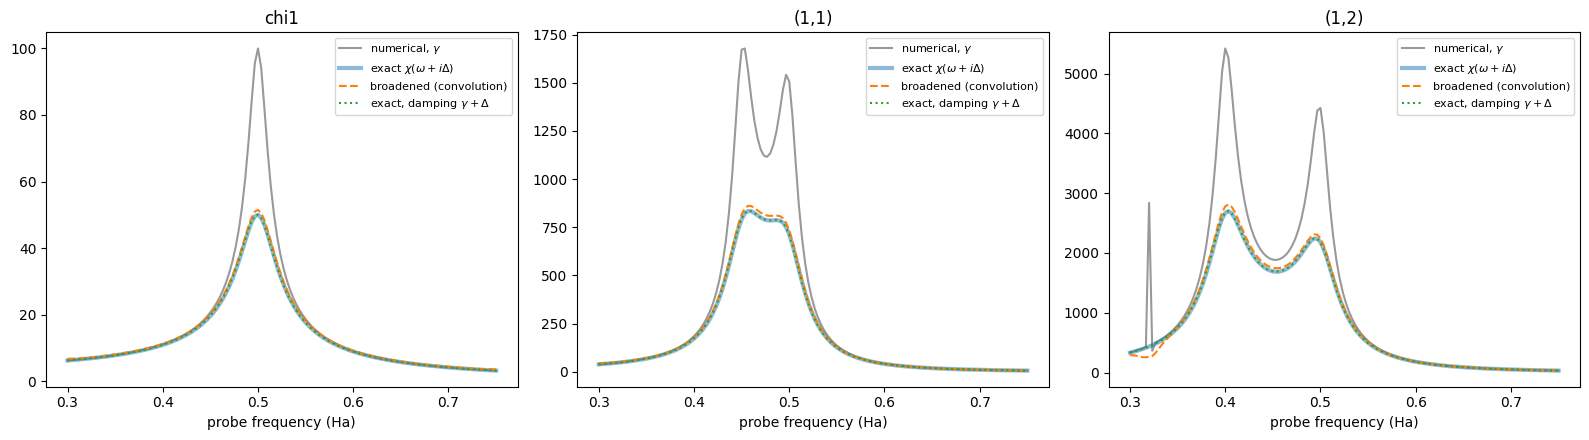

In [34]:
fig,axes = plt.subplots(1,3,figsize=(16,4.5))
for ax,key in zip(axes,['chi1','(1,1)','(1,2)']):
    b_r,ex_c,ex_big = broadened_osc[key]
    ax.plot(w_osc,np.abs(cases[key][0]),'k',alpha=0.4,label=r'numerical, $\gamma$')
    ax.plot(w_osc,np.abs(ex_c),lw=3,alpha=0.5,label=r'exact $\chi(\omega+i\Delta)$')
    ax.plot(w_osc,np.abs(b_r),'--',label='broadened (convolution)')
    ax.plot(w_osc,np.abs(ex_big),':',label=r'exact, damping $\gamma+\Delta$')
    ax.set_title(key)
    ax.set_xlabel('probe frequency (Ha)')
    ax.legend(fontsize=8)
plt.tight_layout()

**Results on the oscillator.** The convolution on the probe grid reproduces the exact $\chi(\omega+i\Delta)$ for the
linear response and for all the keys $(1,m)$ (and for the third order part of $(1,0)$) within $\simeq 3\%$ (4% for
$(1,2)$ in the interior), while the unbroadened keys differ by 100% or more: the method works for the keys linear in the
probe. The residual error is not a discretization error (it is the same in the interior and in the whole window and
it is largest at the resonance): it comes from the tails of the Lorentzian outside the probe window, a fraction
$\simeq (\Delta/\pi)(1/d_1+1/d_2) \simeq 3\%$ of the kernel for a point at the resonance at distances $d_1$, $d_2$ from
the two edges. The renormalization of the kernel replaces the missing tails with the values inside the window, so it
slightly overestimates the peaks; without renormalization the error is of the same size and it is largest at the
edges. For $(1,2)$ the whole window error (14%) is due to an isolated spike of the numerical key at 0.32 Ha (a
failure of the harmonic fit at one frequency), which is spread by the convolution: the method requires keys without
such outliers. On the oscillator the exact continuation and the exact response with damping $\gamma+\Delta$ differ by
1-3% (here the pump-only denominators $D(\pm\omega_P)$ are almost real, far from the resonance), i.e. by less than the
error of the convolution.

### Check on LiF: linear response

The linear response from the sine runs (kx8, $\gamma$ = 0.1 eV) broadened by $\Delta$ is compared with the one of the
kx8 delta run with $\eta = \gamma+\Delta$ (both runs with `NLstep` = 0.01 fs). The comparison is done in the interior
of the 10-20 eV window (at least $3\Delta$ from the edges).

Delta = 0.2 eV: sine broadened vs delta (eta = 0.3 eV), 10.65-19.30 eV: mean rel. diff. 0.032, max 0.065; whole window: max 0.131
Delta = 0.5 eV: sine broadened vs delta (eta = 0.6 eV), 11.54-18.41 eV: mean rel. diff. 0.077, max 0.107; whole window: max 0.242


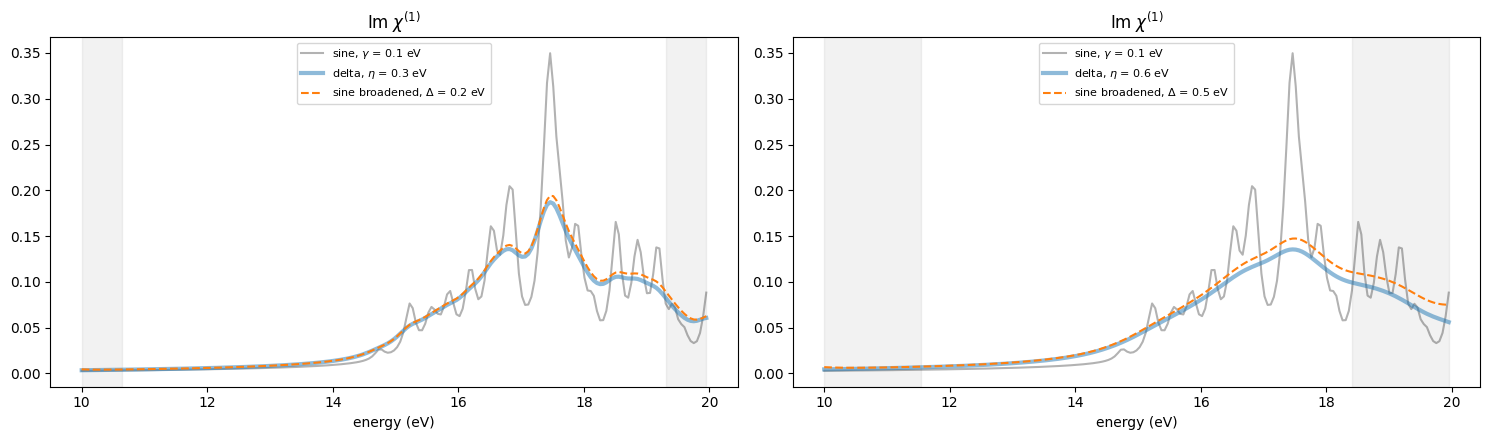

In [35]:
t_delta = np.array(data_delta.IO_TIME_points)
fig,axes = plt.subplots(1,2,figsize=(15,4.5))
for ax,delta in zip(axes,[0.2,0.5]):
    en_d,eps_d = O.Linear_Response(t_delta,data_delta.Polarization[0],data_delta.Efield[0],eta=0.1+delta)
    chi_d = (eps_d-1)/(4*np.pi)
    chi_d = np.interp(freqs,en_d,chi_d.real) + 1j*np.interp(freqs,en_d,chi_d.imag)
    chi_b = lorentzian_broadening(freqs,chi1_sin,delta)
    inner = (freqs > freqs[0]+3*delta) & (freqs < freqs[-1]-3*delta)
    rel = np.abs(chi_b-chi_d)/np.abs(chi_d)
    print('Delta = %.1f eV: sine broadened vs delta (eta = %.1f eV), %.2f-%.2f eV: mean rel. diff. %.3f, max %.3f;'
          ' whole window: max %.3f'%(delta,0.1+delta,freqs[inner][0],freqs[inner][-1],rel[inner].mean(),rel[inner].max(),rel.max()))
    ax.plot(freqs,chi1_sin.imag,'k',alpha=0.3,label=r'sine, $\gamma$ = 0.1 eV')
    ax.plot(freqs,chi_d.imag,lw=3,alpha=0.5,label=r'delta, $\eta$ = %.1f eV'%(0.1+delta))
    ax.plot(freqs,chi_b.imag,'--',label=r'sine broadened, $\Delta$ = %.1f eV'%delta)
    ax.axvspan(freqs[0],freqs[inner][0],color='grey',alpha=0.1)
    ax.axvspan(freqs[inner][-1],freqs[-1],color='grey',alpha=0.1)
    ax.set_xlabel('energy (eV)')
    ax.set_title(r'Im $\chi^{(1)}$')
    ax.legend(fontsize=8)
plt.tight_layout()

**Results on LiF.** With $\Delta$ = 0.2 eV the broadened linear response of the sine runs agrees with the one of the
delta run with $\eta$ = 0.3 eV within 3% on average (6.5% at most) in 10.65-19.30 eV, and the structures of the spectrum
are reproduced. With $\Delta$ = 0.5 eV the agreement is worse (8% on average, 11% at most in the interior) and the
broadened spectrum is systematically above the delta one above 18 eV: the 10-20 eV window cuts the absorption band
of LiF (Im $\epsilon$ extends up to $\sim$ 23 eV, see the k grid section), so the missing tails of the Lorentzian are
large and the renormalization, which replaces them with the values inside the window, overestimates the response near
the upper edge.

So the a posteriori broadening of the keys linear in the probe is reliable for $\Delta \lesssim$ 0.2-0.3 eV in the
present window. For larger broadenings (e.g. the 0.6 eV of the RT spectra) the probe window must extend beyond the
region of interest by several $\Delta$ (e.g. 10-25 eV, which also covers the whole absorption band), or the dynamics
has to be performed with a larger damping.

# Next steps (not yet revised)

The following part of the notebook comes from the previous version and has still to be revised:

1. third order term at the probe frequency $\chi_{(1,1,-1)}$ and the keys $(1,\pm2)$;
2. theory of the transient absorption in terms of the non-linear $\chi$ and its translation into the MPPI quantities;
3. `eval_dchi_neq` (to be checked against the formula, e.g. on the anharmonic oscillator of MPPI) and comparison with
   the RT spectra of D. Sangalli for each delay.

## Third order terms

The $(\omega,\omega_P,-\omega_P)$ term is at the same output frequency of the linear one: since
$$
\chi_{(1,0)}(\omega) = \chi^{(1)}(\omega)+\chi_{(1,1,-1)}(\omega)|E_P(\omega_P)|^2
$$
it is obtained from the difference between the P&p and the probe-only results, with $|E_P(\omega_P)|^2 = E_{0P}^2/4$
(with the MPPI conventions it includes the degeneracy factor 6).

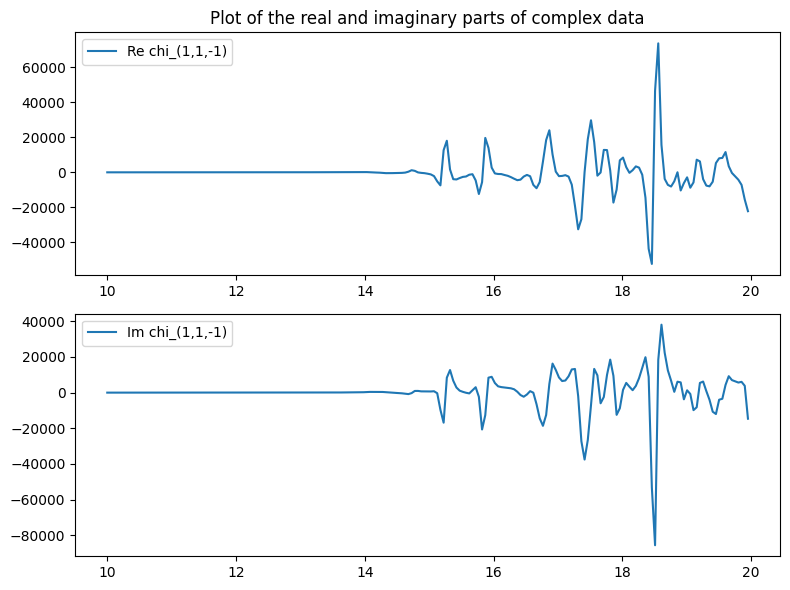

In [36]:
x11m1 = (chi1_Pp - chi1_sin)/(EP**2/4)
Utils.Plot_ComplexArray(freqs,x11m1,label='chi_(1,1,-1)')

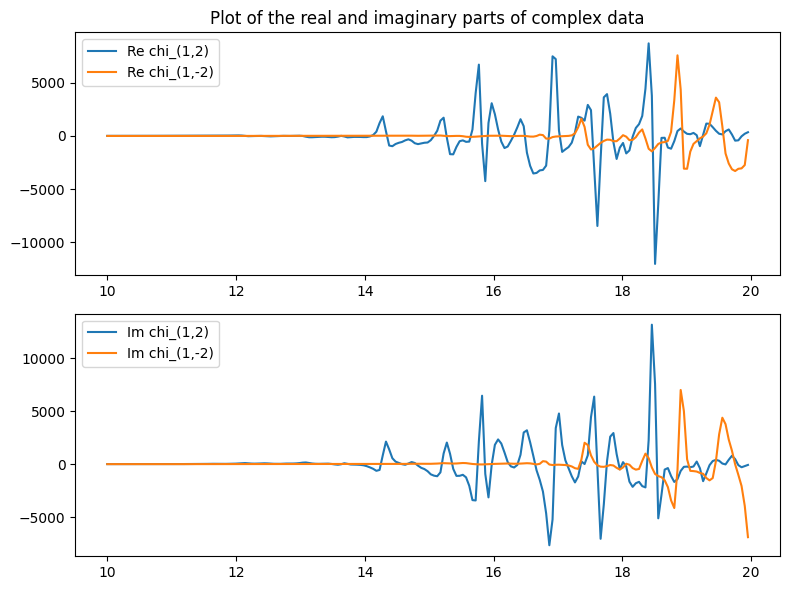

In [37]:
Utils.Plot_ComplexArray(freqs,chi_freqmix[(1,2)],label='chi_(1,2)',data2=chi_freqmix[(1,-2)],label2='chi_(1,-2)')

## Transient absorption from the non-linear $\chi$

The two descriptions are linked by the following equation
\begin{eqnarray}
\chi^{neq,(1)}[E_P](\omega) &=& \chi^{(1)}(\omega;\omega) + \nonumber \\
&+& \left[ \chi^{(2)}(\omega;\omega_P,\omega-\omega_P)\frac{E_{p}(\omega-\omega_P)}{E_p(\omega)} + 
\chi^{(2)}(\omega;-\omega_P,\omega+\omega_P)\frac{E_{p}(\omega+\omega_P)}{E_p(\omega)}
\right]E_{P}(\omega_P)  + \nonumber \\ &+&\left[   
\chi^{(3)}(\omega;\omega_P,\omega_P,\omega-2\omega_P)\frac{E_{p}(\omega-2\omega_P)}{E_p(\omega)} + 
\chi^{(3)}(\omega;\omega_P,-\omega_P,\omega) + \right. \nonumber \\ &&\left.
\chi^{(3)}(\omega;-\omega_P,-\omega_P,\omega+2\omega_P)\frac{E_{p}(\omega+2\omega_P)}{E_p(\omega)}
\right]E^2_{P}(\omega_P)
\end{eqnarray}

### Translation in terms of the MPPI quantities (MPPI >= 1.3)

`Xn_frequency_mixing(...).compute_Xn()[0][(n,m)]` at the probe frequency $\omega$ is the ratio between the component of
$P$ at $n\omega + m\omega_P$ and the product of the field amplitudes $E(\pm\omega)^{|n|} E(\pm\omega_P)^{|m|}$,
with $E(\omega) = (i E_0/2) e^{i\omega t_0}$ and $E(-\omega) = E(\omega)^*$ (Boyd, Nonlinear Optics, Sec. 1.3).
These quantities include the degeneracy factor: $\chi_{(1,\pm1)} = 2\chi^{(2)}$, $\chi_{(1,\pm2)} = 3\chi^{(3)}$
and the third order part of $\chi_{(1,0)}$ is $6\chi^{(3)}(\omega;\omega,\omega_P,-\omega_P)|E_P(\omega_P)|^2$.
The pump induced change of the response at the frequency $\omega$ reads

$$
\delta\chi(\omega) = \sum_{m=\pm1,\pm2} \chi_{(1,m)}(\omega - m\omega_P)\frac{E_p(\omega - m\omega_P)}{E_p(\omega)}
E_P(\mathrm{sign}(m)\,\omega_P)^{|m|} + \left[\chi_{(1,0)}(\omega) - \chi^{(1)}(\omega)\right]
$$

so the key $(1,m)$ is read at the probe frequency $\omega - m\omega_P$ (shifted grid) and the pump enters with its
complex amplitude $E_P(\omega_P) = (i E_{0P}/2) e^{i\omega_P t_{0P}}$. To be checked against `eval_dchi_neq`.

### Utility functions

In [38]:
def eval_dchi_neq(omega,omega_P,tau,EP,x11,x1m1,x11m1,x12,x1m2):
    """
    We compute the variation of the neq absorption

    Args:
        omega : energy range of the probe (Hartree)
        omega_P : energy of the pump (Hartree)
        tau : time delay of the probe w.r.t. the pump (fs)
        EP : amplitude of the pump
        x11 : chi(omega+omega_P;omega_P,omega)
        x1m1 : chi(omega-omega_P;-omega_P,omega)
        x11m1 : chi(omega,omega_P,-omega_P,omega) extracted as the non-linear part
            of chi(omega)
        x12 : chi(omega+2*omega_P;omega_P,omega_P,omega)
        x1m2 : chi(omega-2*omega_P;-omega_P,-omega_P,omega)
    """
    domega = omega[1]-omega[0]
    ind_oP = round(omega_P/domega)
    omega_eff = omega[2*ind_oP:-2*ind_oP]
    phase = omega_P*tau*Const.FsToAu # corresponds to omega*t/hbar

    F2_1 = x11*np.exp(-1j*phase)
    F2_2 = x1m1*np.exp(1j*phase)
    F2_sum = F2_1[2*ind_oP:] + F2_2[:-2*ind_oP]
    F2_sum_cut = F2_sum[ind_oP:-ind_oP] # cut the part the is not present in the cubic terms

    F3_1 = x12*np.exp(-1j*2*phase)
    F3_2 = x11m1
    F3_3 = x1m2*np.exp(1j*2*phase)
    F3_sum = F3_1[4*ind_oP:] + F3_2[2*ind_oP:-2*ind_oP] + F3_3[:-4*ind_oP]

    dchi_neq = F2_sum_cut*EP+F3_sum*EP**2

    return omega_eff,dchi_neq


def build_delta_dict(path='.'):
    """
    Scan all folders inside `path` and build a dictionary
    using the value contained in 'deltaXX.XXfs' as key.

    Returns
    -------
    dict
        Dictionary of the form

            {
                delta_value: folder_name
            }

    Notes
    -----
    If multiple folders have the same delta value,
    the last one found will overwrite the previous one.
    """

    delta_dict = {}

    # Regular expression used to extract the delta value
    # Example match: delta10.00fs -> 10.00
    pattern = re.compile(r'delta([0-9]+\.?[0-9]*)fs')

    # Loop over all entries in the directory
    for folder in os.listdir(path):

        full_path = os.path.join(path, folder)

        # Process only directories
        if os.path.isdir(full_path):

            # Search for the delta pattern in the folder name
            match = pattern.search(folder)

            if match:

                # Convert extracted value to float
                delta = float(match.group(1))

                # Store folder name in the dictionary
                delta_dict[delta] = folder

    return delta_dict

Now we compare the result for the transient absorption spectrum computed within the two approach.

To this scope we refer to the equation already discussed at the beginning of the notebook that (since we are interested in the variation w.r.t the equilibrium value)
can be written as

\begin{eqnarray}
\delta\chi^{neq,(1)}[E_P](\omega) &=& \chi^{neq,(1)}[E_P](\omega) - \chi^{(1)}(\omega;\omega) = \\
&& \left[ \chi^{(2)}(\omega;\omega_P,\omega-\omega_P)\frac{E_{p}(\omega-\omega_P)}{E_p(\omega)} + 
\chi^{(2)}(\omega;-\omega_P,\omega+\omega_P)\frac{E_{p}(\omega+\omega_P)}{E_p(\omega)}
\right]E_{P}(\omega_P)  + \nonumber \\ &+&\left[   
\chi^{(3)}(\omega;\omega_P,\omega_P,\omega-2\omega_P)\frac{E_{p}(\omega-2\omega_P)}{E_p(\omega)} + 
\chi^{(3)}(\omega;\omega_P,-\omega_P,\omega) + \right. \nonumber \\ &&\left.
\chi^{(3)}(\omega;-\omega_P,-\omega_P,\omega+2\omega_P)\frac{E_{p}(\omega+2\omega_P)}{E_p(\omega)}
\right]E^2_{P}(\omega_P)
\end{eqnarray}

In order to write an equation useful to compute the $\delta\chi^{neq}$ we analyze the previous formula addend by addend.

We parametrize the $\omega$ dependence in terms of the values of the probe, so that the two addends at the second order reads

$$
 \chi^{(2)}(\omega+\omega_P;\omega_P,\omega)\frac{E_{p}(\omega)}{E_p(\omega+\omega_P)} + 
\chi^{(2)}(\omega-\omega_P;-\omega_P,\omega)\frac{E_{p}(\omega)}{E_p(\omega-\omega_P)}
$$

Assuming tha the probe is a delta centred at $t_0$ in the time domain, its FT is given by $e^{i\omega t_0}$ so the ratios of probe fields simplify to

$$
\chi^{(2)}(\omega+\omega_P;\omega_P,\omega)e^{-i\omega_P \, t_0} + 
\chi^{(2)}(\omega-\omega_P;-\omega_P,\omega)e^{i\omega_P \, t_0}
$$

In the same way we can rewrite the third order addends as

$$
\chi^{(3)}(\omega;\omega_P,-\omega_P,\omega) +
\chi^{(3)}(\omega+2\omega_P;\omega_P,\omega_P,\omega)e^{-2i\omega_P \, t_0} + 
\chi^{(3)}(\omega-2\omega_P;-\omega_P,-\omega_P,\omega)e^{2i\omega_P \, t_0}
$$

The function `eval_dchi_neq` builds these terms on the common frequency range.
It has still to be checked against the formula in terms of the MPPI quantities written above.

In [39]:
x11 = chi_freqmix[(1,1)]
x1m1 = chi_freqmix[(1,-1)]
x12 = chi_freqmix[(1,2)]
x1m2 = chi_freqmix[(1,-2)]

RT results of D. Sangalli (kx16): absorption spectrum for each pump-probe delay

In [40]:
path = 'Davide_data/20250312_Report_simulations_data_kx16_ball/'
deltas_folder = build_delta_dict(path=path)
deltas = sorted(deltas_folder.keys())
deltas

[5.25,
 8.5,
 8.75,
 9.0,
 9.25,
 9.5,
 9.75,
 10.0,
 10.25,
 10.5,
 10.75,
 11.0,
 11.25,
 11.5,
 11.75,
 12.0,
 12.25,
 12.5,
 12.75,
 13.0,
 13.25,
 13.5,
 13.75,
 14.0,
 14.25,
 14.5,
 14.75,
 15.0,
 15.25,
 15.5,
 15.75,
 16.0,
 16.25,
 16.5,
 16.75,
 17.0,
 17.25,
 17.5,
 17.75,
 18.0,
 18.25,
 18.5,
 18.75,
 19.0,
 19.25,
 19.5,
 19.75,
 20.0,
 20.25,
 20.5,
 20.75,
 21.0,
 21.25,
 21.5,
 21.75,
 22.0,
 22.25,
 22.5,
 22.75,
 23.0,
 23.25,
 23.5,
 23.75,
 24.0]

Parse file Davide_data/20250312_Report_simulations_data_kx16_ball/td-ip-ber_3.0as_inv_1-15b_qsf90pi1.56_6.0E9_deph0.0eV_delta5.25fs_Pp_NL/o-abs_0-50eV_sm0.6eV.YPP-eps_along_E


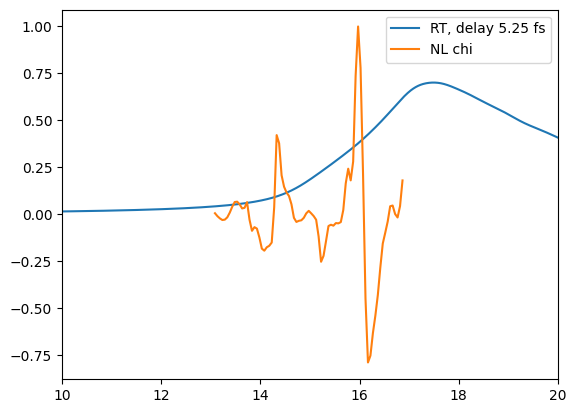

In [41]:
tau = deltas[0]

data = P.YamboOutputParser.from_file(os.path.join(path,deltas_folder[tau],'o-abs_0-50eV_sm0.6eV.YPP-eps_along_E'))['YPP-eps_along_E']
energy = data['col1']
eps_im = data['col2']
omega_eff, dchi_neq = eval_dchi_neq(omega,omega_P,tau,EP,x11,x1m1,x11m1,x12,x1m2)

abs_chi = np.imag(dchi_neq)/max(np.imag(dchi_neq))

plt.plot(energy,eps_im/max(eps_im),label='RT, delay %s fs'%tau)
plt.plot(omega_eff*Const.HaToeV,abs_chi,label='NL chi')
plt.xlim(10,20)
plt.legend()